In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses, observableClasses
import datetime
import numpy as np
from tqdm import tqdm
from scipy.optimize import curve_fit
from scipy import stats
import pickle
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("style.mplstyle")

In [2]:
dataset = baseClasses.Data()

In [3]:
mask= (
    ((dataset.data.index > datetime.datetime(2024, 4, 30)) & (dataset.data.index < datetime.datetime(2024, 7, 1)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [4]:
hvv = sensorClasses.Sensor(dataset, id=1013)
hvi = sensorClasses.Sensor(dataset, id=1014)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


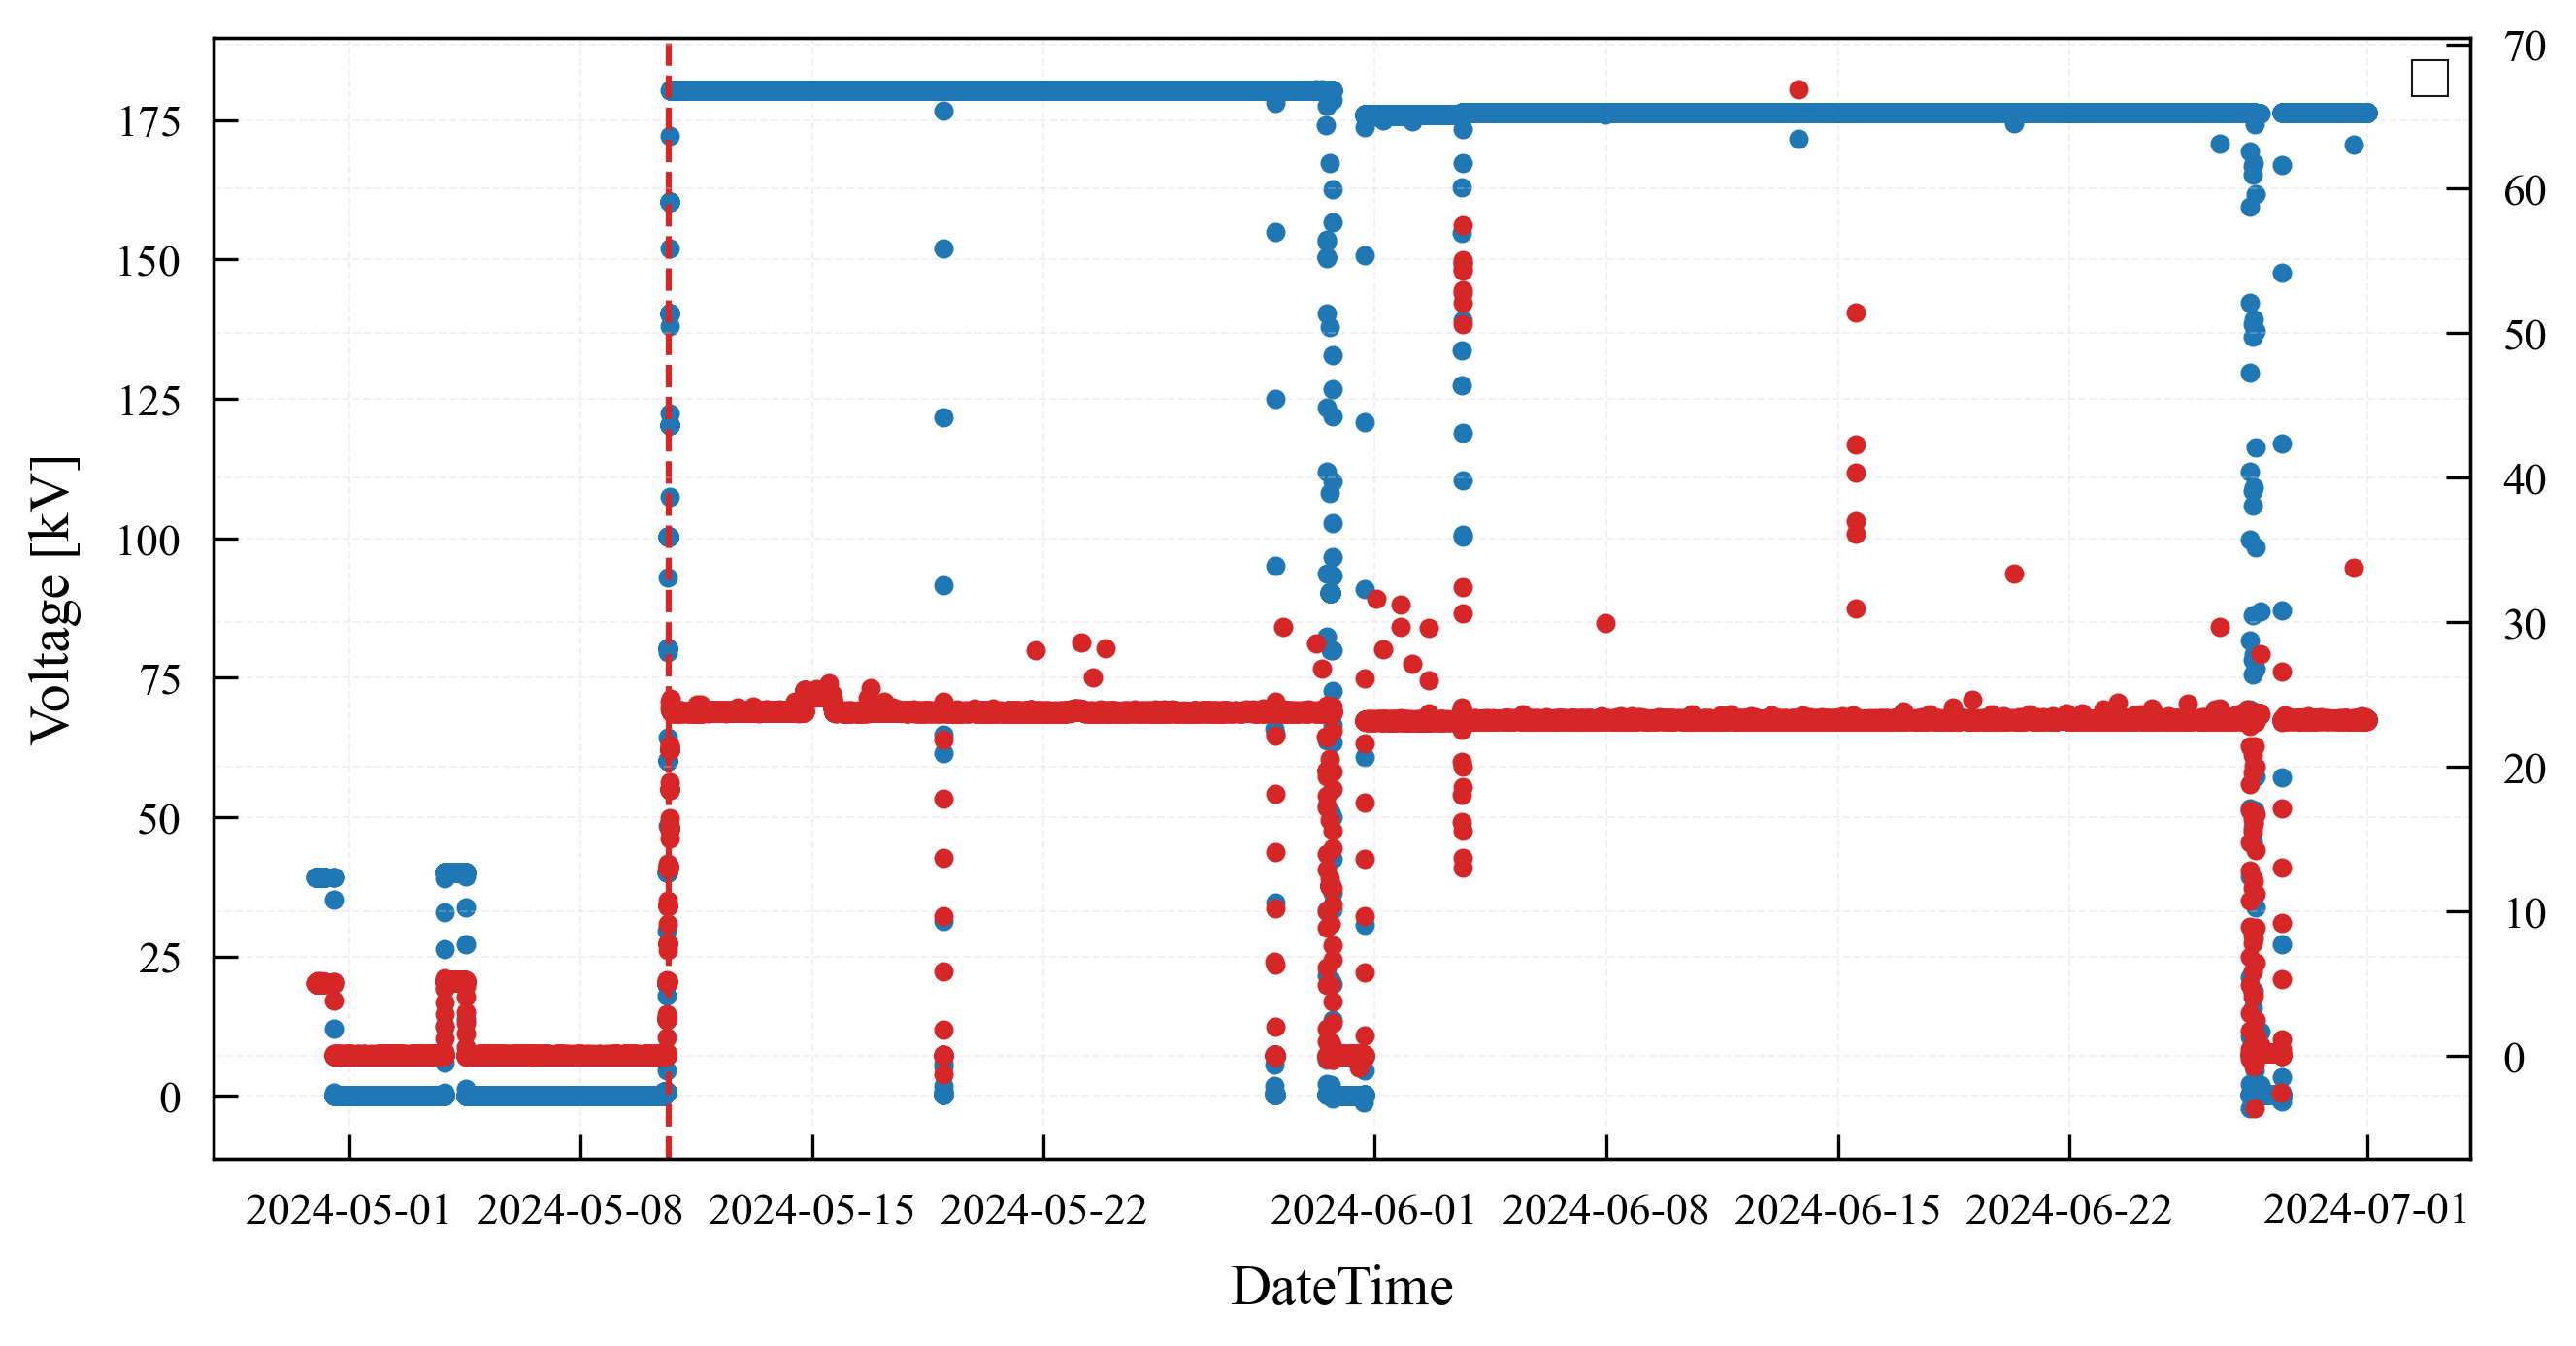

In [5]:
fig, axes = plt.subplots(1,1)
axes2 = axes.twinx()
axes.plot(hvv.data.index.values, 1e-3*hvv.data.values, marker="o", linestyle="None")
axes2.plot(hvi.data.index.values, hvi.data.values, marker="o", color="tab:red", linestyle="None")
axes.set_xlabel("DateTime")
axes.set_ylabel("Voltage [kV]")
axes.axvline(datetime.datetime(2024, 5, 10, 16), color="tab:red", linestyle="--")
# axes.set_xlim(datetime.datetime(2024, 12, 1), datetime.datetime(2024, 12, 25))
axes.legend()
fig.set_size_inches(10, 5)


In [6]:
tgrad = systemClasses.System(dataset, "TGRAD")
hawai = systemClasses.System(dataset, "HAWAI")
prm = systemClasses.System(dataset, "PRM")
apa1 = systemClasses.System(dataset, sensor_names=["APA1LAr1", "APA1LAr4"])
apa2 = systemClasses.System(dataset, sensor_names=["APA2LAr1", "APA2LAr2", "APA2LAr3", "APA2LAr4"])
apa3 = systemClasses.System(dataset, sensor_names=["APA3LAr1", "APA3LAr2", "APA3LAr3", "APA3LAr4"])
apa4 = systemClasses.System(dataset, sensor_names=["APA4LAr1", "APA4LAr4"])
inlet = systemClasses.System(dataset, sensor_names=["1-I", "3-I", "4-I"])
upstream = systemClasses.System(dataset, sensor_names=["2-M", "4-M"])
middle = systemClasses.System(dataset, sensor_names=["1-M", "3-M"])
downstream = systemClasses.System(dataset, sensor_names=["1-U", "2-U", "3-U", "4-U"])
pipes = systemClasses.System(dataset, "PIPE")
pumps = systemClasses.System(dataset, "PP")
tgrad.calibrate("SECOND_POFF_OCTOBER")
hawai.calibrate("SECOND_POFF_EMPTY")
prm.calibrate("SECOND_POFF_OCTOBER")
pipes.calibrate("SECOND_POFF_OCTOBER")
pumps.calibrate("SECOND_POFF_OCTOBER")
inlet.calibrate("SECOND_POFF_OCTOBER")
upstream.calibrate("SECOND_POFF_OCTOBER")
middle.calibrate("SECOND_POFF_OCTOBER")
downstream.calibrate("SECOND_POFF_OCTOBER")
apa1.calibrate("SECOND_POFF_OCTOBER")
apa2.calibrate("SECOND_POFF_OCTOBER")
apa3.calibrate("SECOND_POFF_OCTOBER")
apa4.calibrate("SECOND_POFF_OCTOBER")


Initializing Custom Sensors: 100%|██████████| 2/2 [00:00<00:00,  9.30sensor/s]


ERROR: Channel (TE0120) not found


Initializing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00, 10.62sensor/s]


ERROR: Channel (TE0120) not found


Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:05<00:00,  8.39sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 48/48 [00:00<00:00, 66.92sensor/s]
Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:02<00:00, 11.00sensor/s]
Calibrating HAWAI Sensors - Calibration Name: SECOND_POFF_EMPTY: 100%|██████████| 24/24 [00:00<00:00, 102.29sensor/s]
Equalizing PRM Sensors: 100%|██████████| 6/6 [00:00<00:00,  9.33sensor/s]
Calibrating PRM Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 6/6 [00:00<00:00, 101.18sensor/s]
Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  9.92sensor/s]


ERROR: Channel (TE0120) not found


Calibrating PIPE Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 12/12 [00:00<00:00, 97.06sensor/s]
Equalizing PP Sensors: 100%|██████████| 2/2 [00:00<00:00, 10.71sensor/s]
Calibrating PP Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 93.95sensor/s]
Equalizing Custom Sensors: 100%|██████████| 3/3 [00:00<00:00, 10.19sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 3/3 [00:00<00:00, 98.21sensor/s]
Equalizing Custom Sensors: 100%|██████████| 2/2 [00:00<00:00, 10.00sensor/s]


ERROR: Channel (TE0120) not found


Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 90.98sensor/s]
Equalizing Custom Sensors: 100%|██████████| 2/2 [00:00<00:00, 10.00sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 92.42sensor/s]
Equalizing Custom Sensors: 100%|██████████| 4/4 [00:00<00:00,  9.91sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 4/4 [00:00<00:00, 99.71sensor/s]
Equalizing Custom Sensors: 100%|██████████| 2/2 [00:00<00:00, 10.27sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 85.18sensor/s]
Equalizing Custom Sensors: 100%|██████████| 4/4 [00:00<00:00, 16.14sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 4/4 [00:00<00:00, 97.77sensor/s]
Equalizing Custom Sensors: 100%|██████████| 4/4 [00:00<00:00, 17.31sensor/s]
Calibrating Custom Sensor

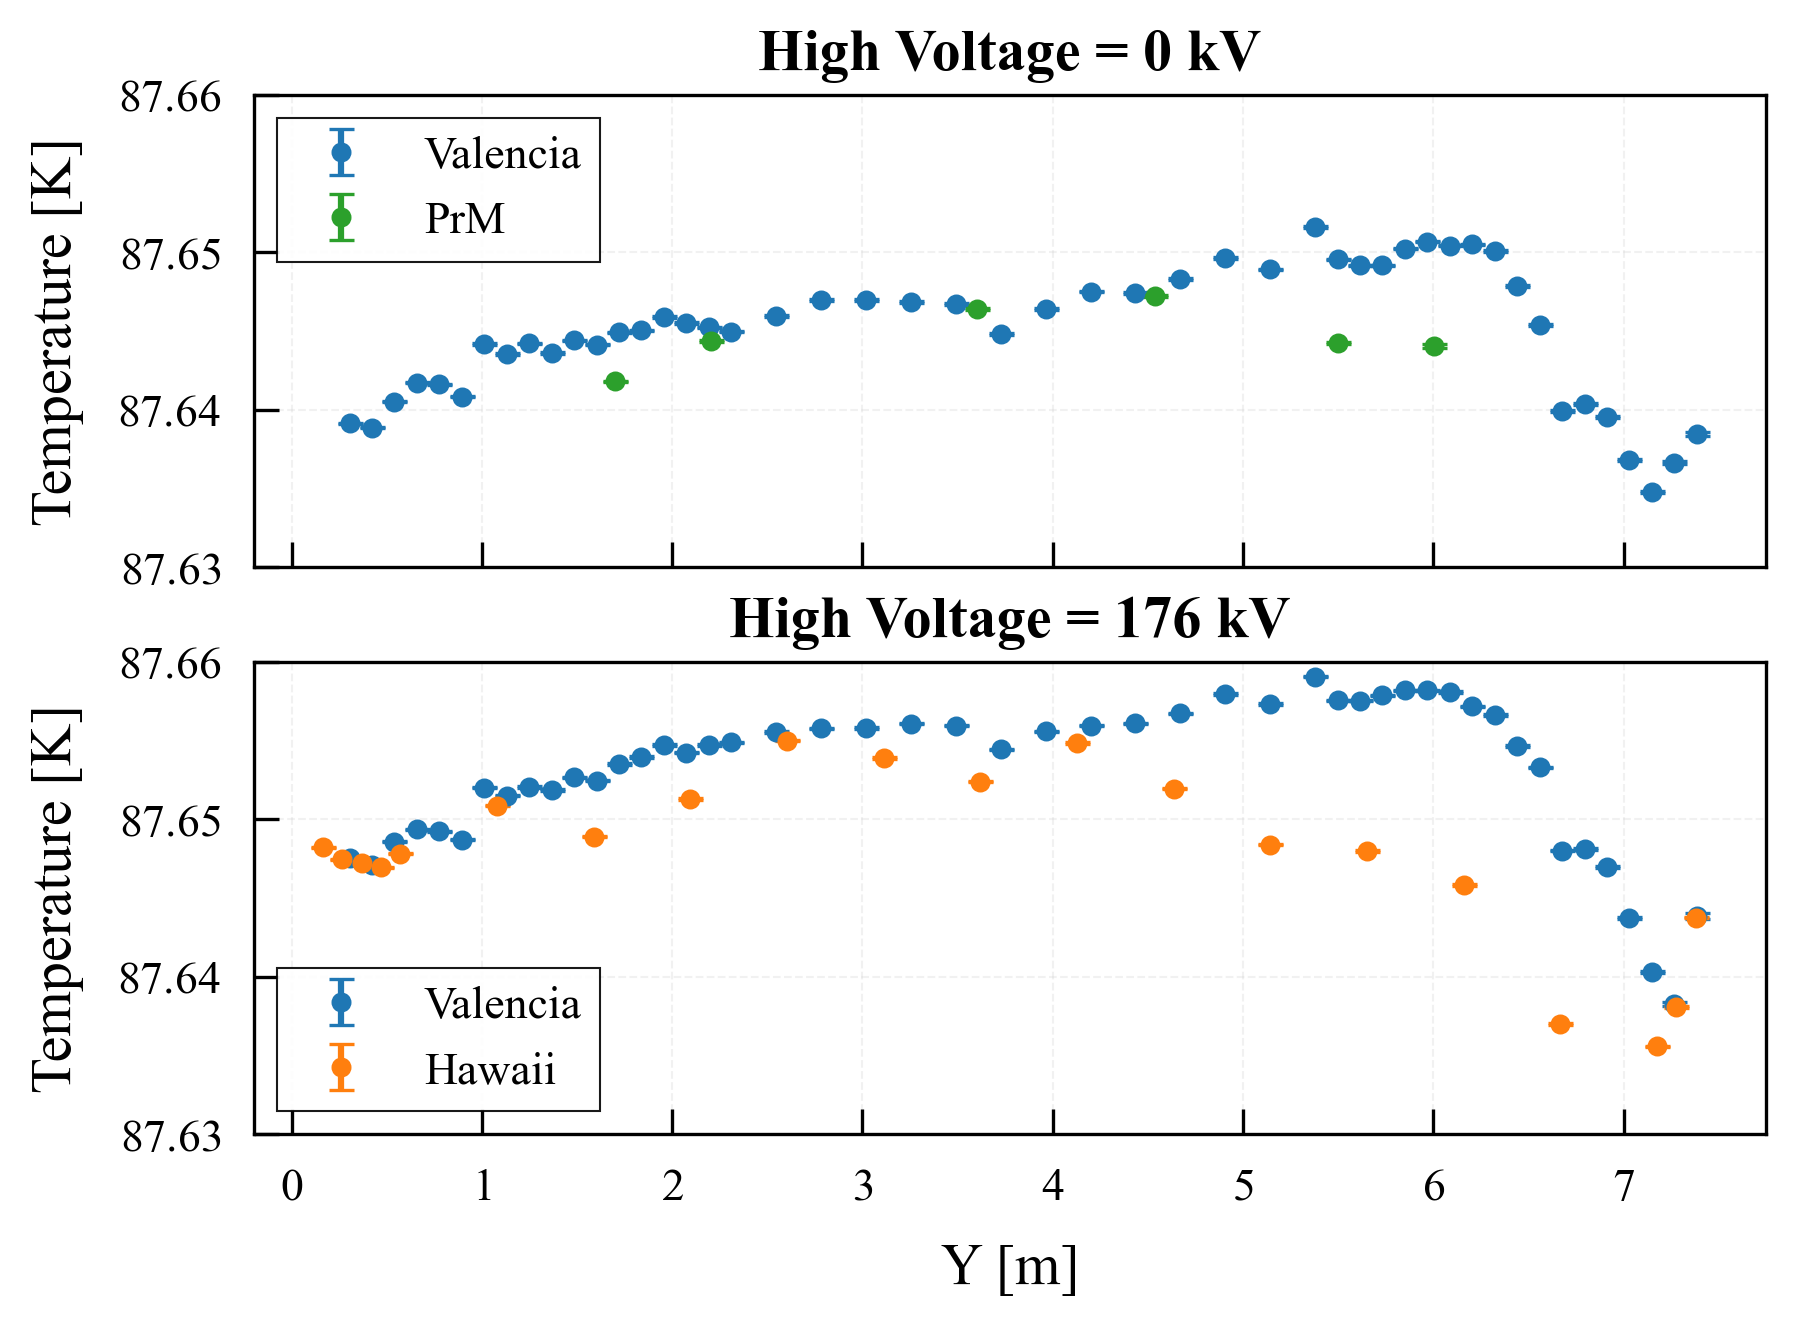

In [7]:
fig, axes = plt.subplots(2,1, sharex=True)
tgrad.makeProfiles(tini=datetime.datetime(2024, 5, 7, 12), tend=datetime.datetime(2024, 5, 8, 12))
axes[0].errorbar(1e-3*tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, marker="o", linestyle="None", color="tab:blue", label="Valencia")
prm.makeProfiles(tini=datetime.datetime(2024, 5, 7, 12), tend=datetime.datetime(2024, 5, 8, 12))
axes[0].errorbar(1e-3*prm.profiles["Y"].values, prm.profiles["temp"].values, yerr=prm.profiles["err"].values, marker="o", linestyle="None", color="tab:green", label="PrM")
axes[0].set_ylabel("Temperature [K]")
axes[0].set_title(fr"High Voltage = {1e-3*hvv.data.loc[datetime.datetime(2024, 5, 7, 12):datetime.datetime(2024, 5, 8, 12)].mean():.0f} kV")
axes[0].legend()
axes[0].set_ylim(87.63, 87.66)

tgrad.makeProfiles(tini=datetime.datetime(2024, 6, 15, 12), tend=datetime.datetime(2024, 6, 16, 13))
axes[1].errorbar(1e-3*tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, marker="o", linestyle="None", color="tab:blue", label="Valencia")
hawai.makeProfiles(tini=datetime.datetime(2024, 6, 15, 12), tend=datetime.datetime(2024, 6, 16, 13))
axes[1].errorbar(1e-3*hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, marker="o", linestyle="None", color="tab:orange", label="Hawaii")
axes[1].set_xlabel("Y [m]")
axes[1].set_ylabel("Temperature [K]")
axes[1].set_title(fr"High Voltage = {1e-3*hvv.data.loc[datetime.datetime(2024, 6, 15, 12):datetime.datetime(2024, 6, 16, 13)].mean():.0f} kV")
axes[1].legend()
axes[1].set_ylim(87.63, 87.66)
fig.savefig("/Users/jcapo/cernbox/DUNE-IFIC/Publications/NP04_TMS/SENSITIVITY/HVOFF-HVON_valencia_prm_hawaii.png")


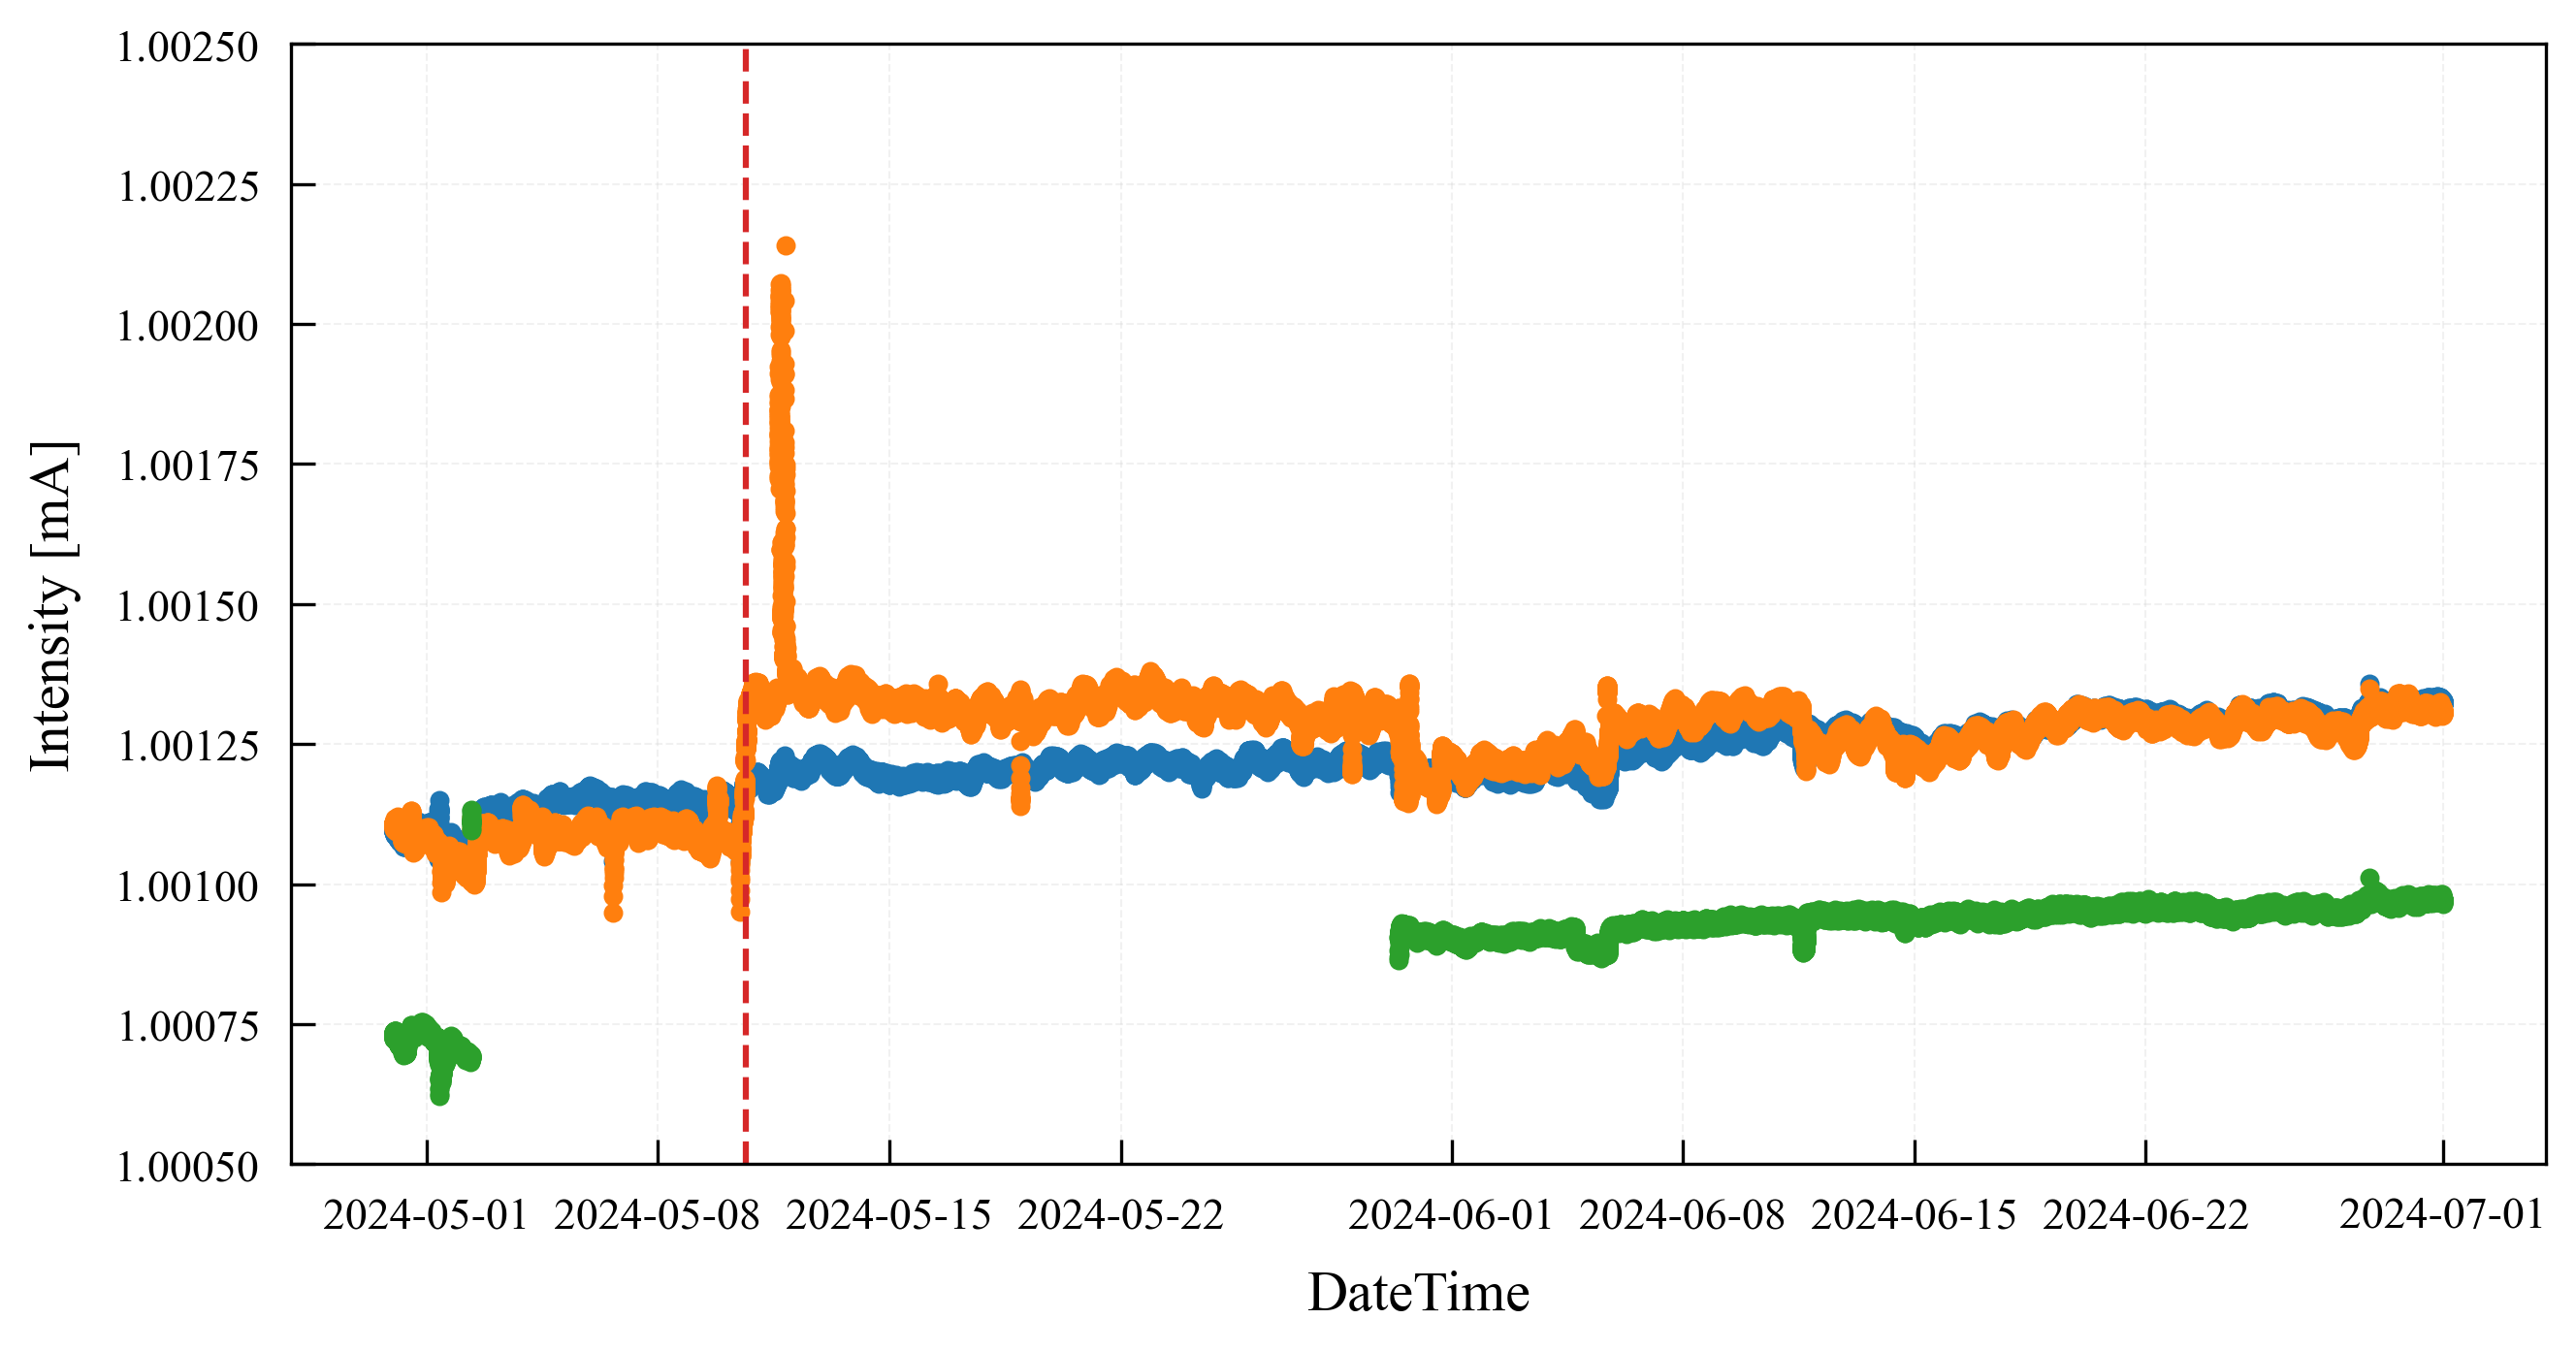

In [8]:
mux1 = muxClasses.MUX(dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset, boardNumber=4)

fig, axes = plt.subplots(1,1)
axes.plot(mux1.data.index.values, mux1.data.values, marker="o", linestyle="None")
axes.plot(mux2.data.index.values, mux2.data.values, marker="o", linestyle="None")
axes.plot(mux3.data.index.values, mux3.data.values, marker="o", linestyle="None")
axes.plot(mux4.data.index.values, mux4.data.values, marker="o", linestyle="None")
axes.set_xlabel("DateTime")
axes.set_ylabel("Intensity [mA]")
axes.set_ylim(1.0005, 1.0025)
axes.axvline(datetime.datetime(2024, 5, 10, 16), color="tab:red", linestyle="--")
fig.set_size_inches(10, 5)



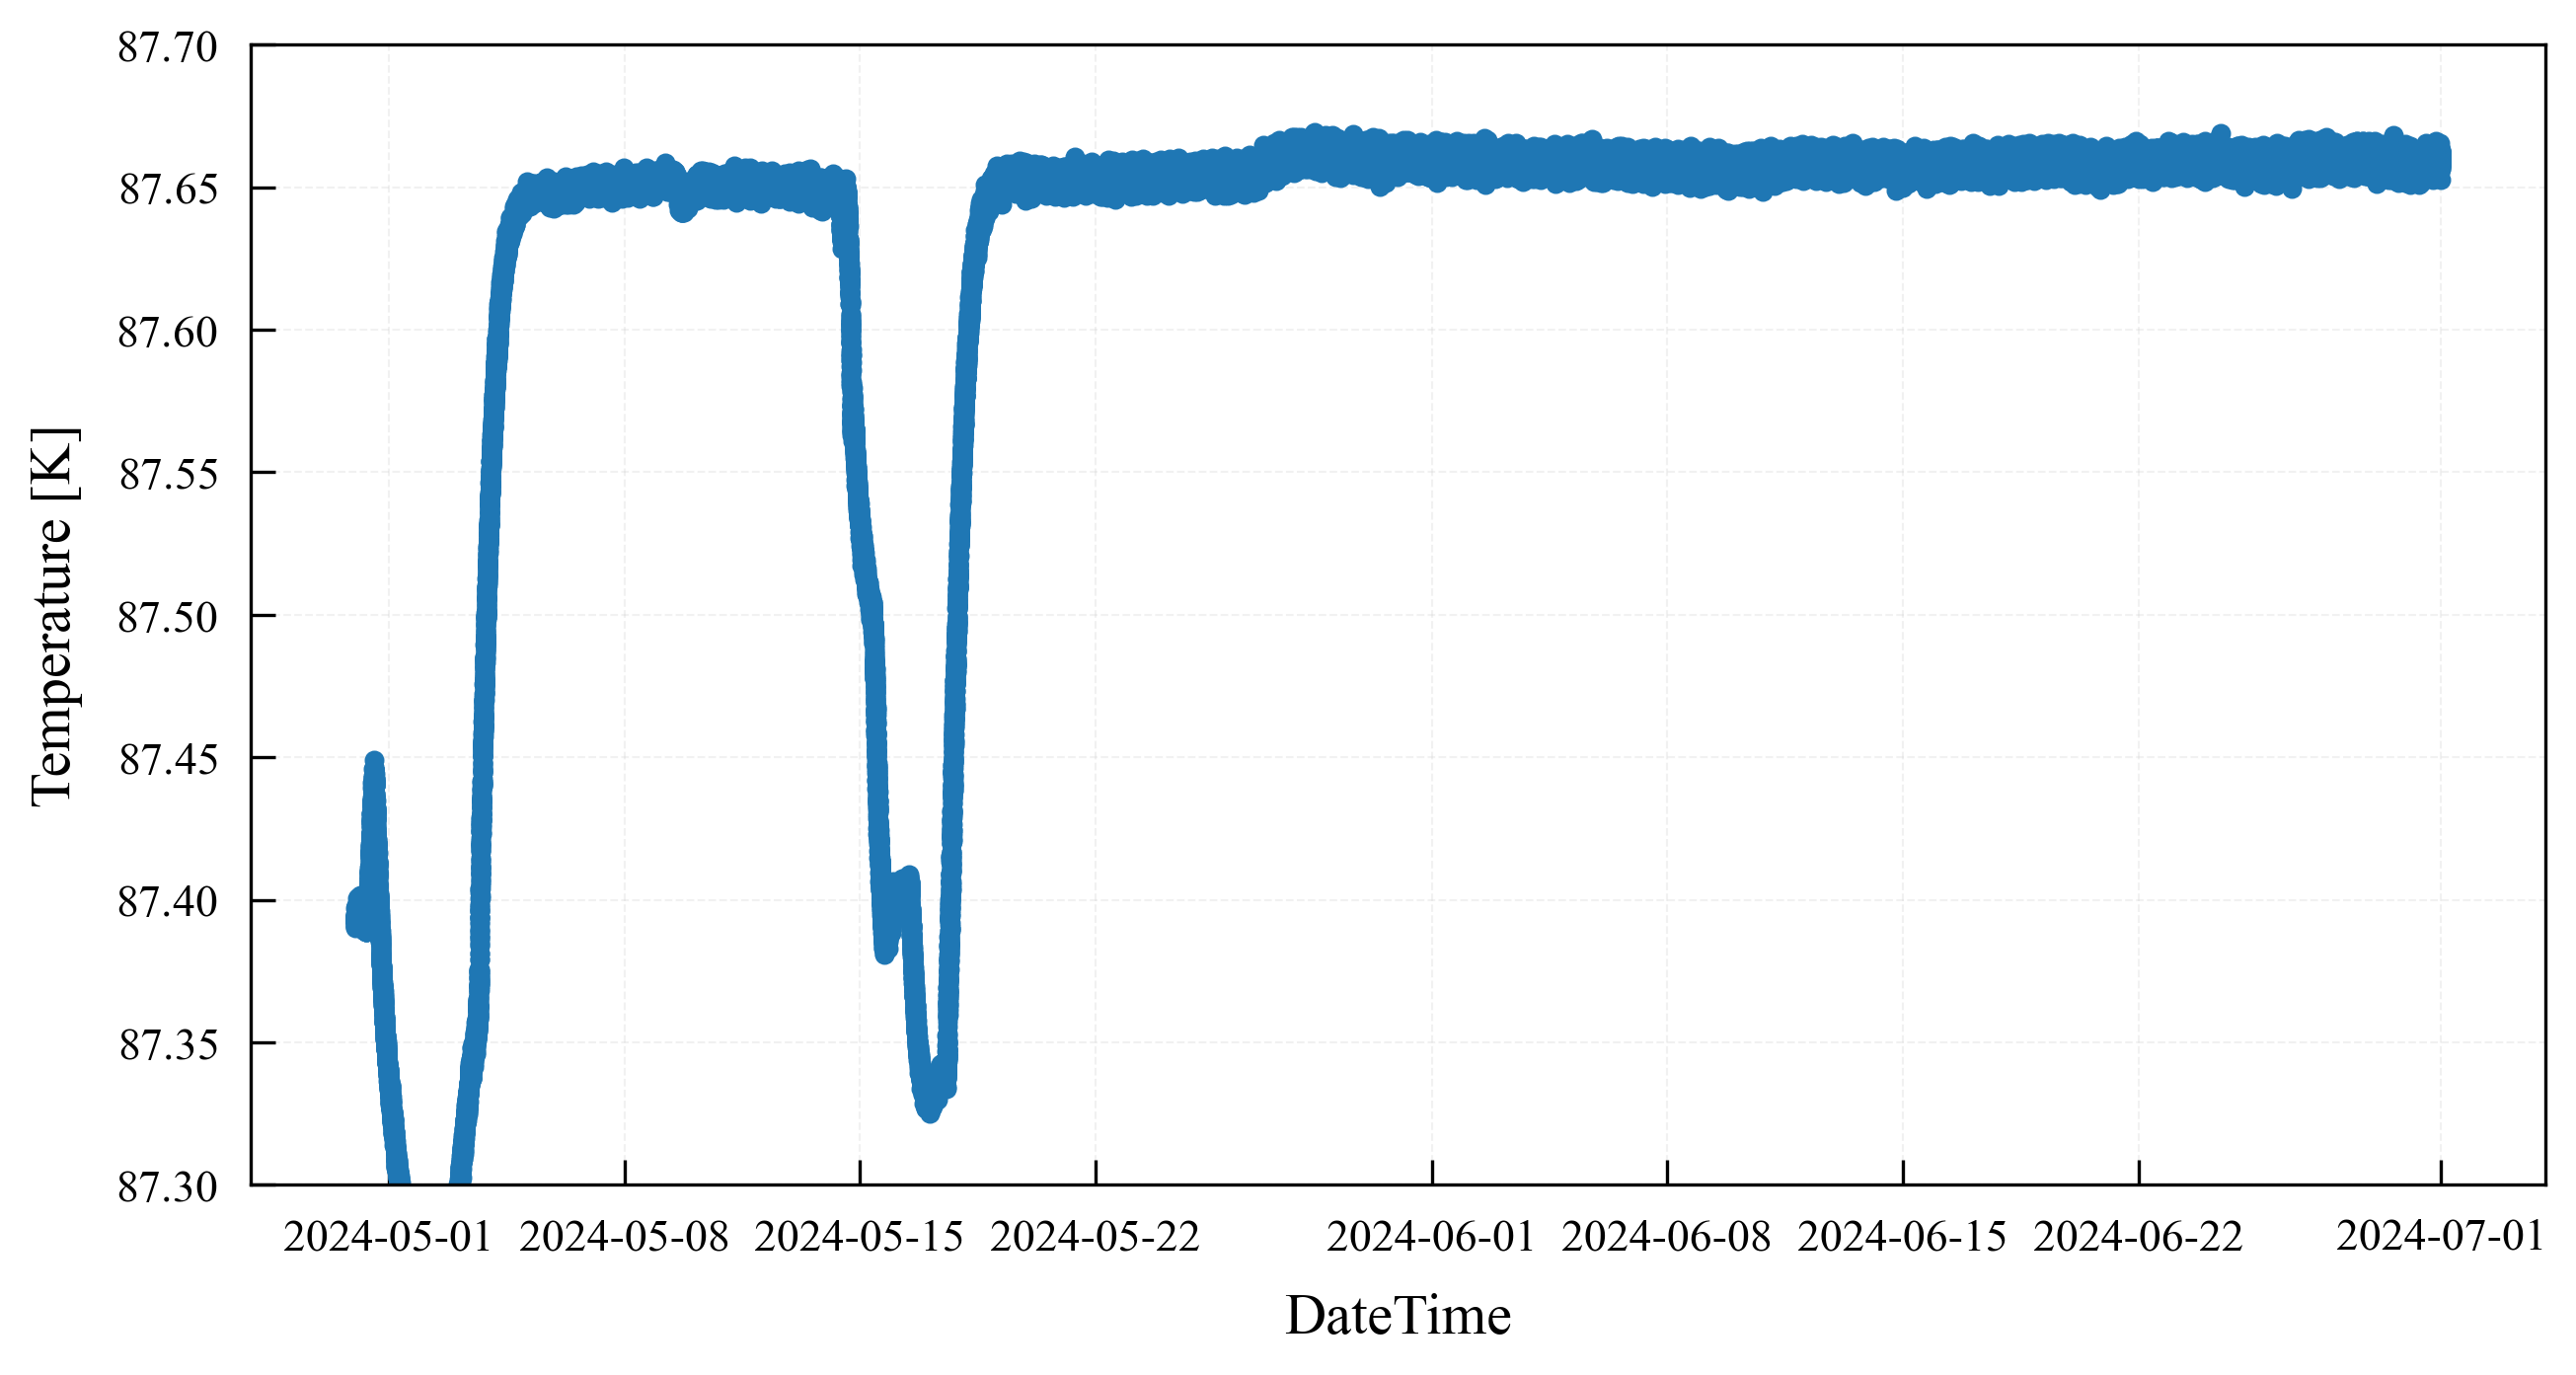

In [9]:
fig, axes = plt.subplots(1,1)
axes.plot(tgrad.sensors[39651].data.index.values, tgrad.sensors[39651].data.values, marker="o", linestyle="None")
axes.set_xlabel("DateTime")
axes.set_ylabel("Temperature [K]")
axes.set_ylim(87.3, 87.7)
fig.set_size_inches(10, 5)




# Temperature Map as a function of High Voltage (V)

In [10]:
dataset = baseClasses.Data()

In [19]:
mask= (
    ((dataset.data.index > datetime.datetime(2024, 11, 13)) & (dataset.data.index < datetime.datetime(2024, 11, 18)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [20]:
hvv = sensorClasses.Sensor(dataset, id=1013)
hvi = sensorClasses.Sensor(dataset, id=1013)

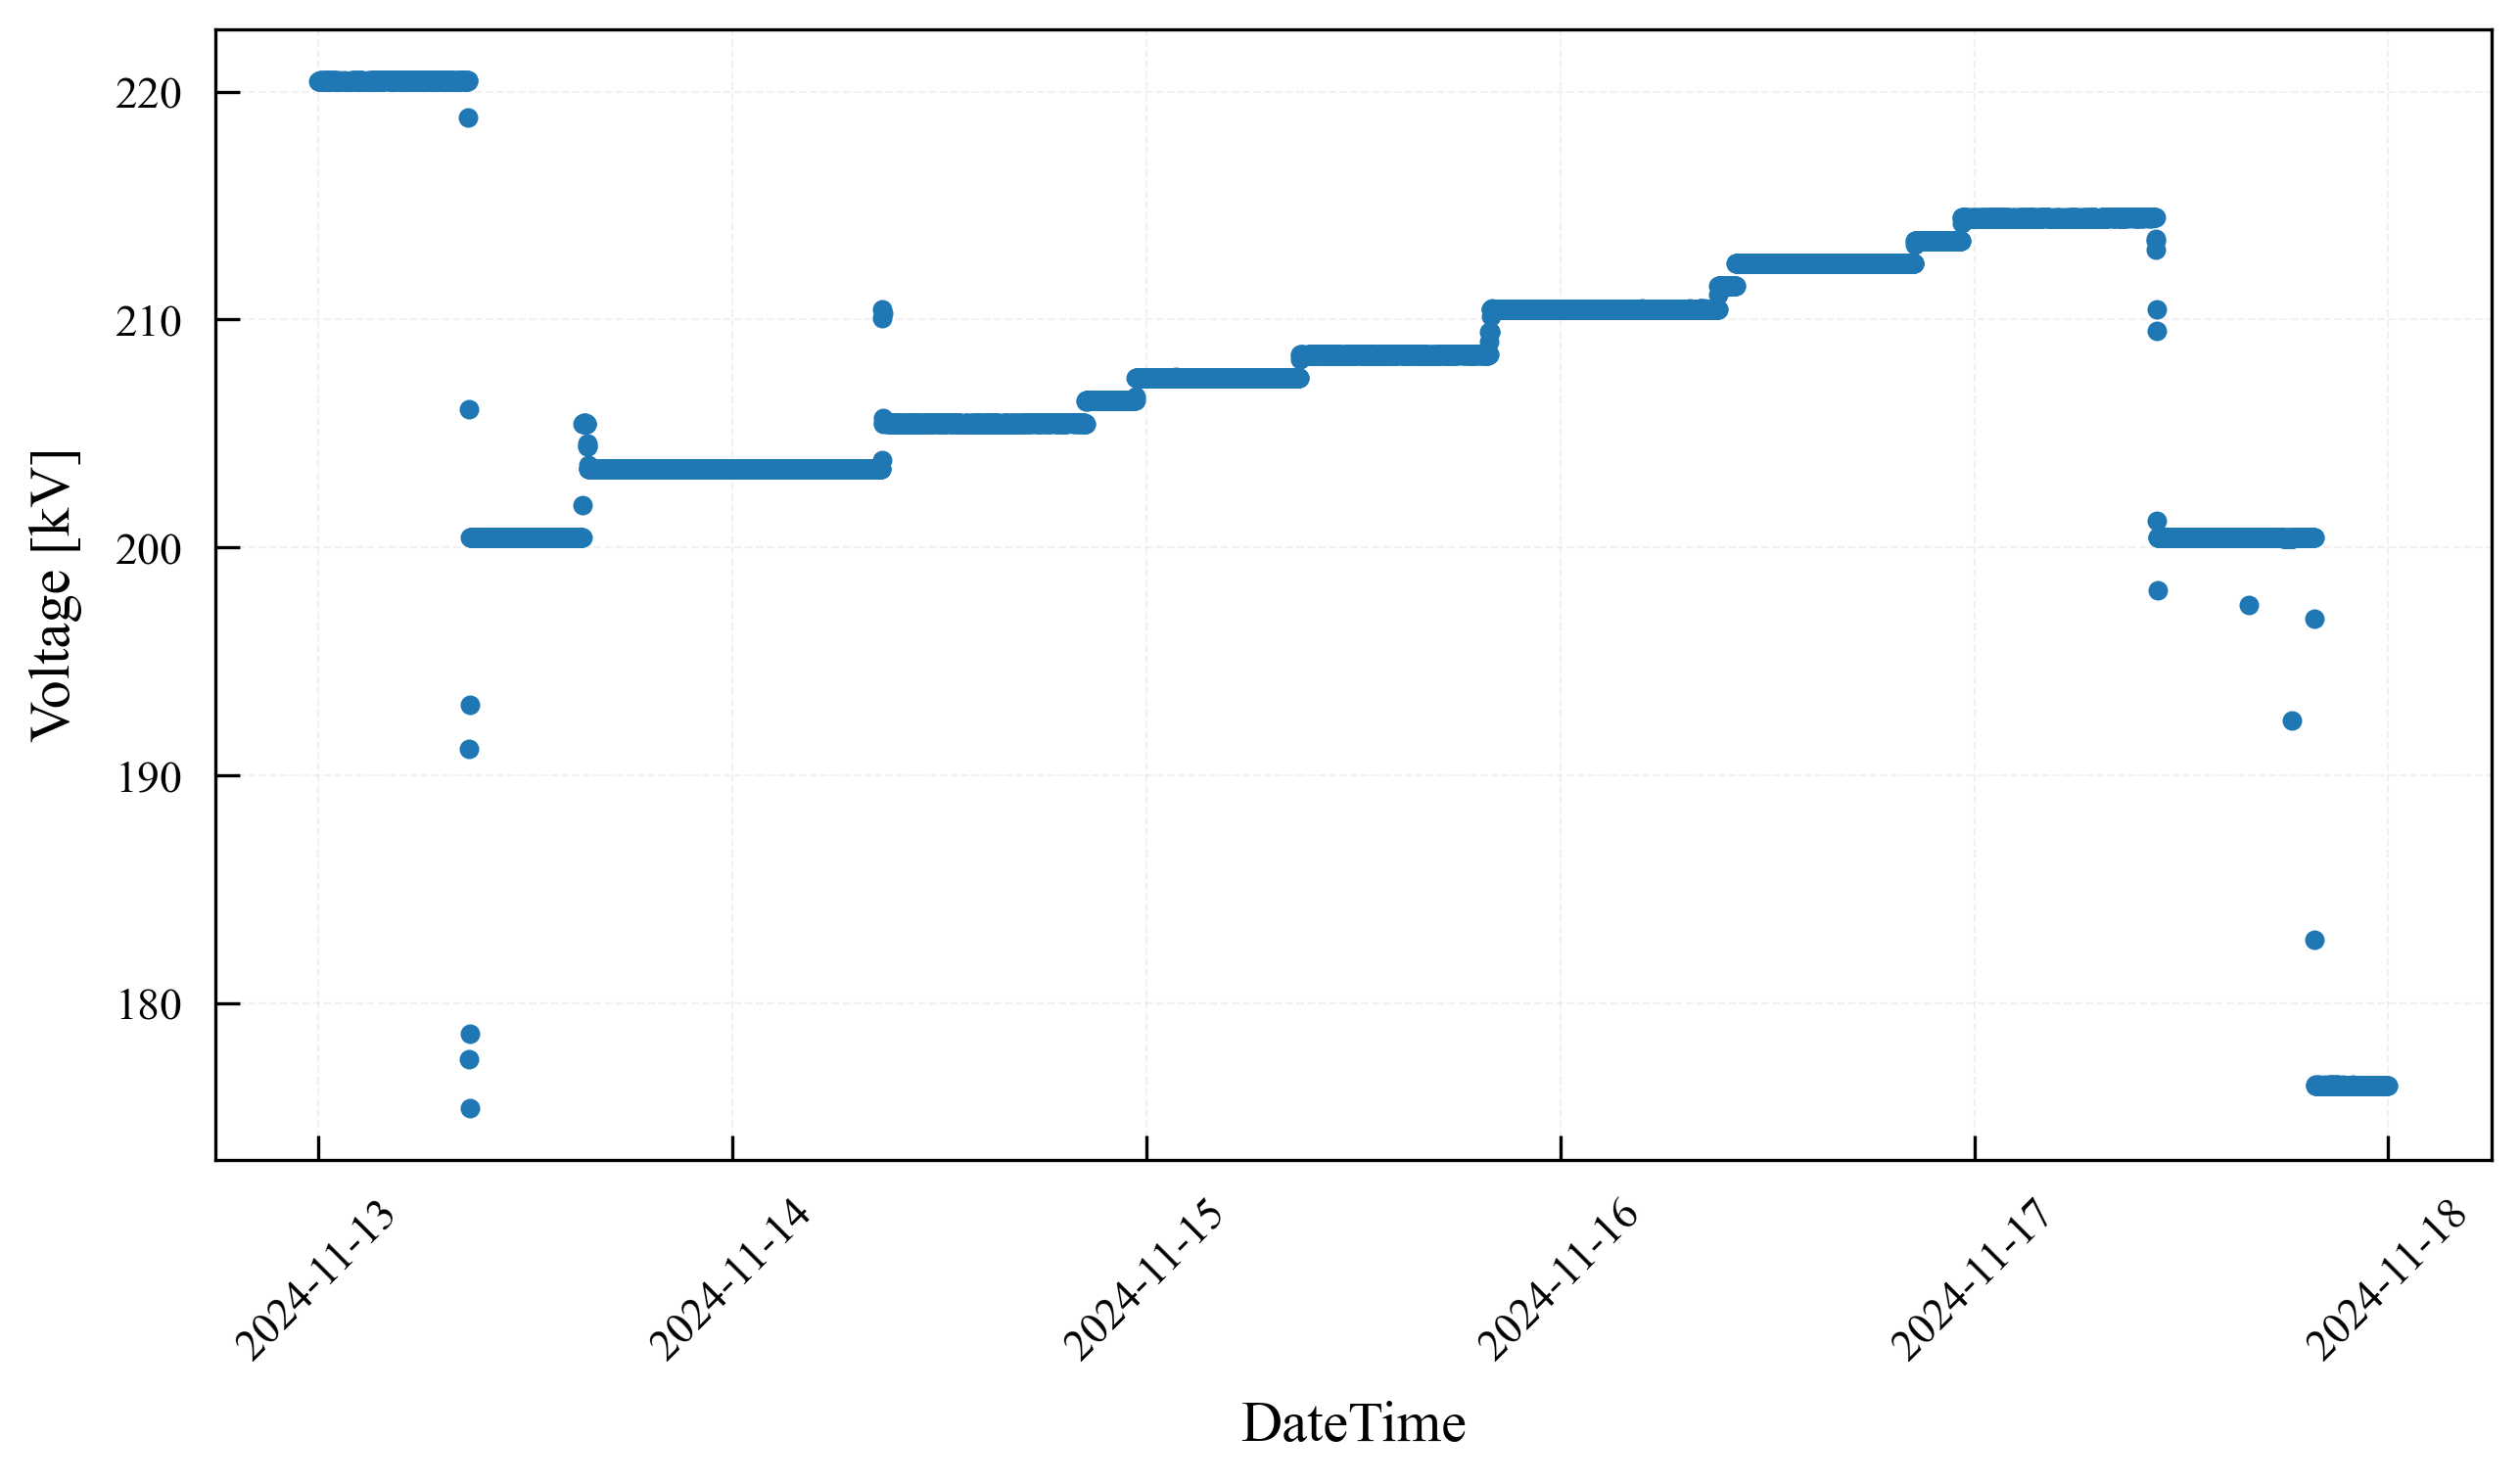

In [21]:
fig, axes = plt.subplots(1,1)
axes.plot(hvv.data.index.values, 1e-3*hvv.data.values, marker="o", linestyle="None")
axes.set_xlabel("DateTime")
axes.set_ylabel("Voltage [kV]")
axes.tick_params(axis="x", rotation=45)
fig.set_size_inches(10, 5)


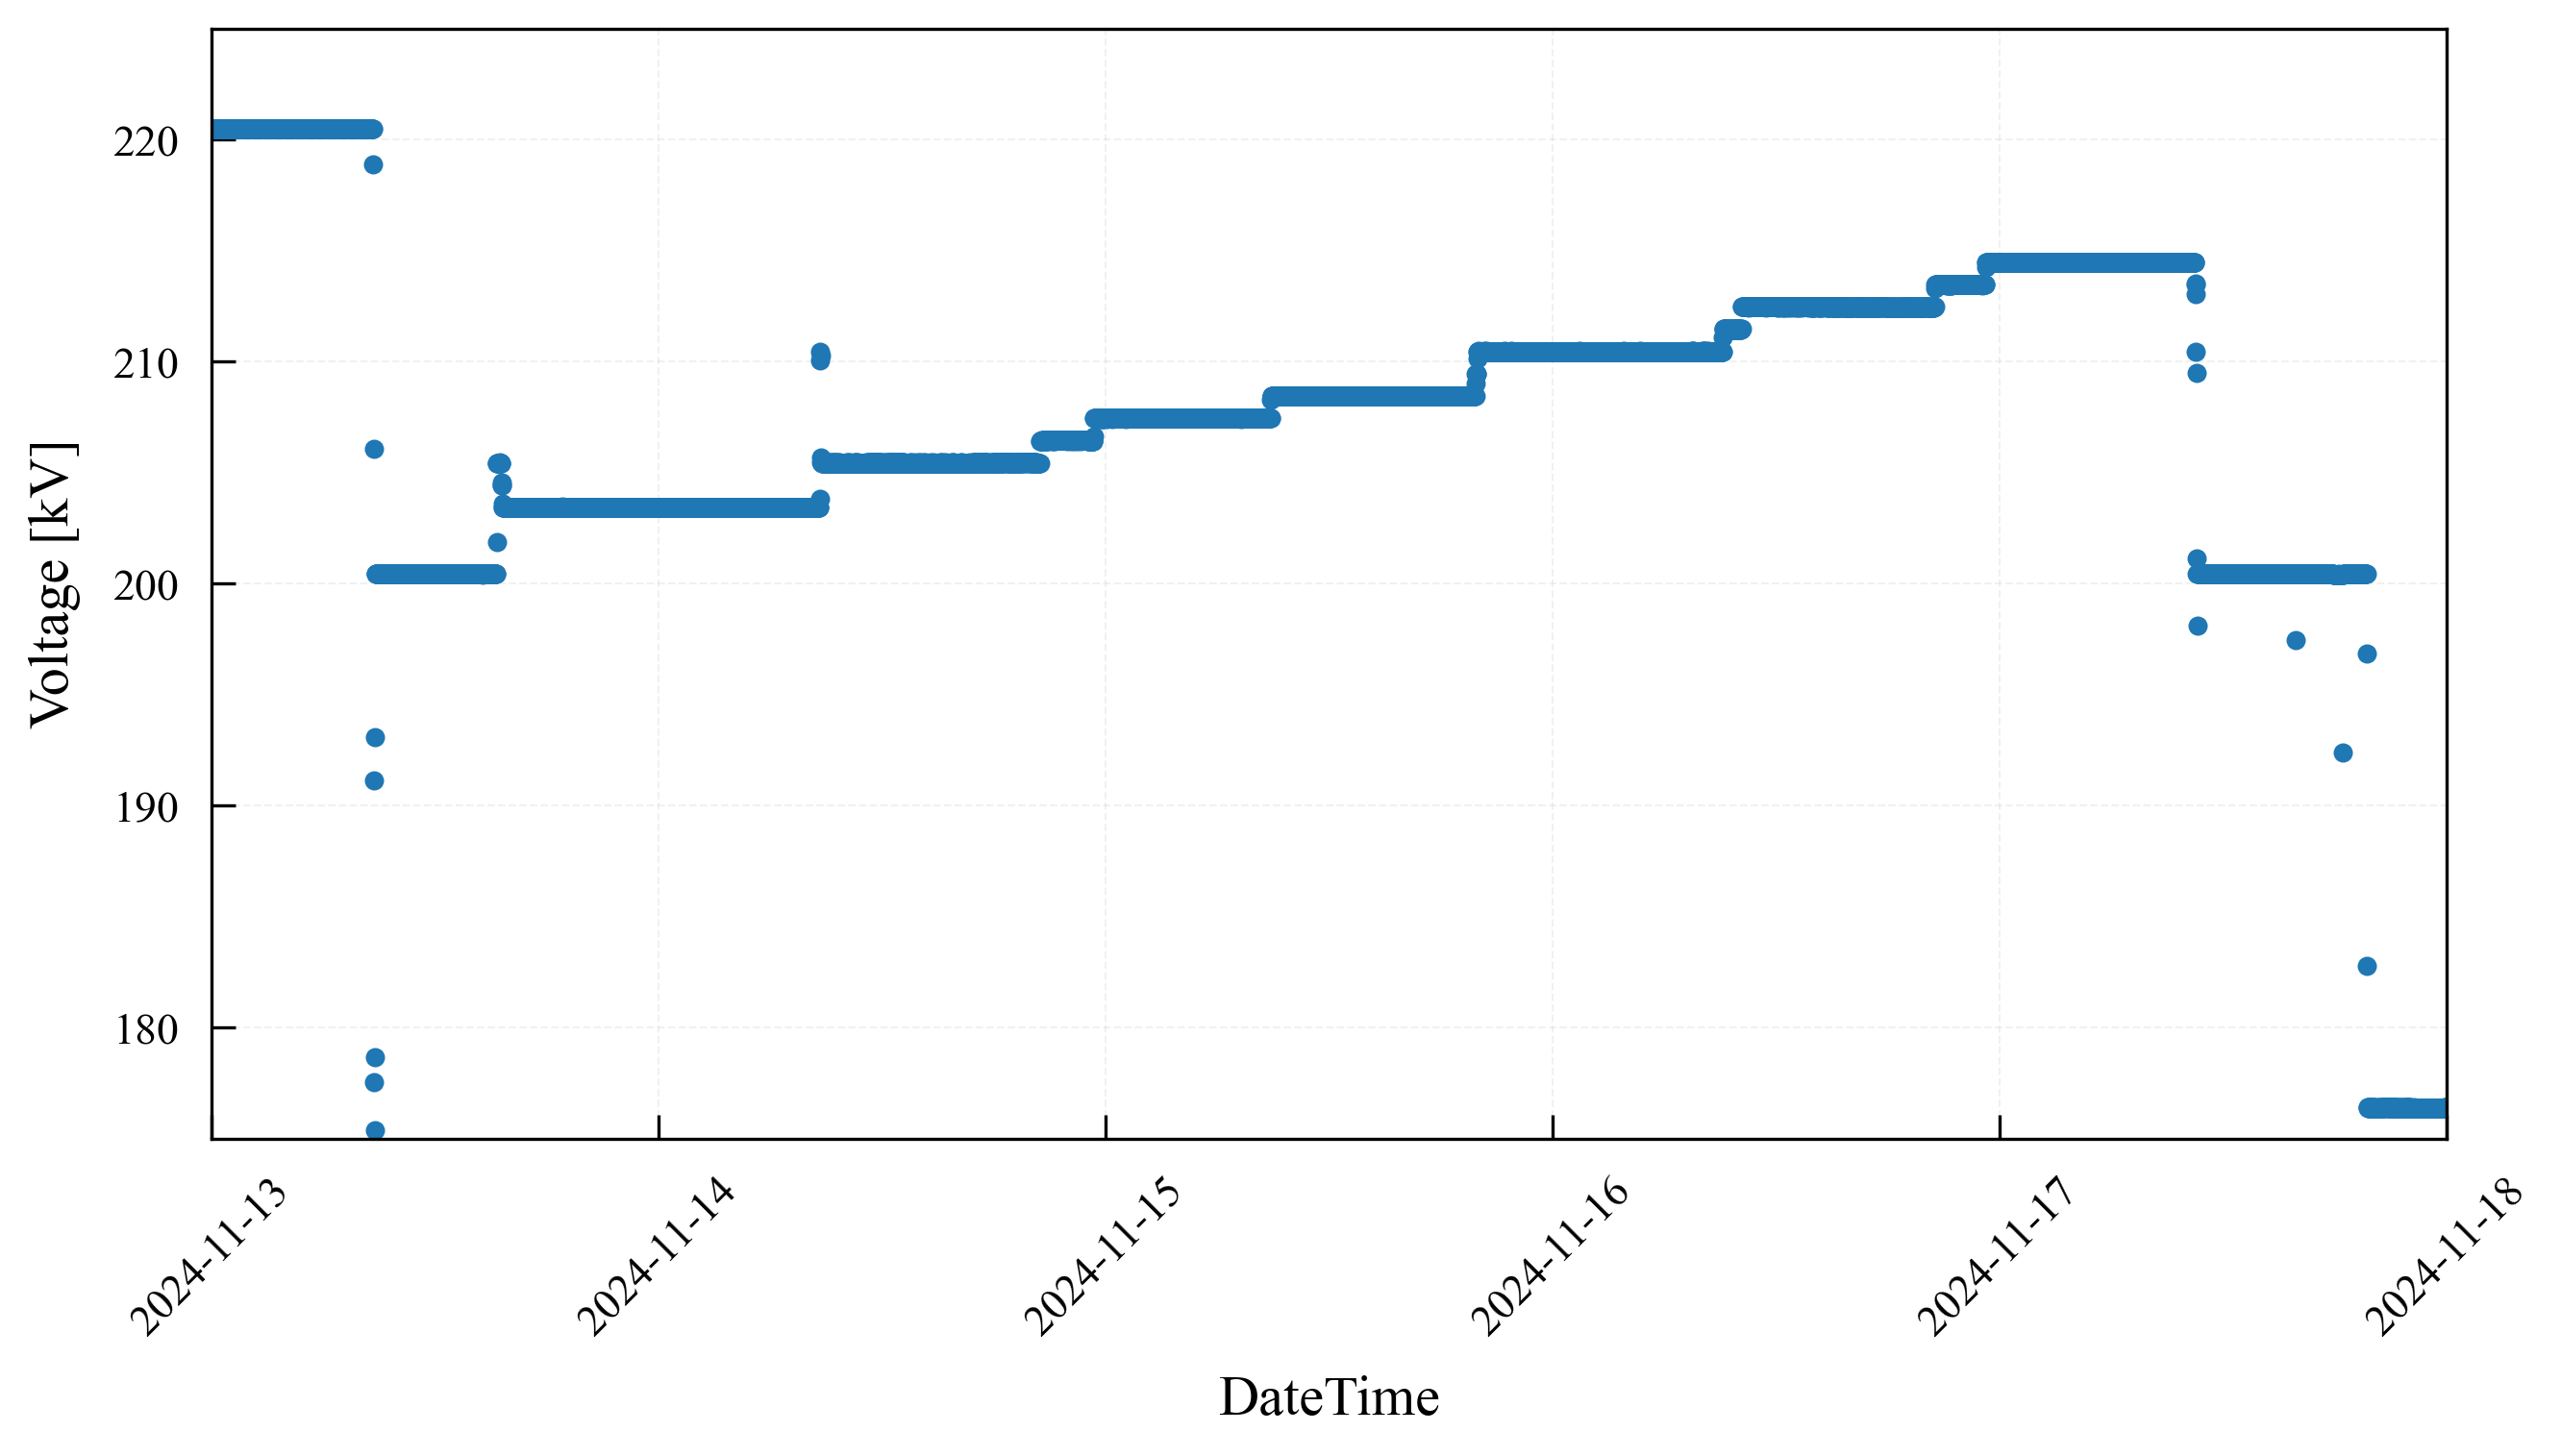

In [22]:
fig, axes = plt.subplots(1,1)
axes.plot(hvv.data.index.values, 1e-3*hvv.data.values, marker="o", linestyle="None")
axes.set_xlabel("DateTime")
axes.set_ylabel("Voltage [kV]")
axes.tick_params(axis="x", rotation=45)
# axes.set_xlim(datetime.datetime(2024, 11, 13), datetime.datetime(2024, 11, 18))
axes.set_ylim(175, 225)

t0_ini, t0_end = datetime.datetime(2024, 11, 9, 12), datetime.datetime(2024, 11, 10, 12)
t1_ini, t1_end = datetime.datetime(2024, 11, 13, 10), datetime.datetime(2024, 11, 13, 15)
t2_ini, t2_end = datetime.datetime(2024, 11, 13, 16, 30), datetime.datetime(2024, 11, 14, 8)
t3_ini, t3_end = datetime.datetime(2024, 11, 14, 9, 30), datetime.datetime(2024, 11, 14, 20)
t4_ini, t4_end = datetime.datetime(2024, 11, 14, 21, 0), datetime.datetime(2024, 11, 14, 22, 45)
t5_ini, t5_end = datetime.datetime(2024, 11, 15, 1, 0), datetime.datetime(2024, 11, 15, 8)
t6_ini, t6_end = datetime.datetime(2024, 11, 15, 10), datetime.datetime(2024, 11, 15, 19)
t7_ini, t7_end = datetime.datetime(2024, 11, 15, 21), datetime.datetime(2024, 11, 16, 8)
t8_ini, t8_end = datetime.datetime(2024, 11, 16, 11), datetime.datetime(2024, 11, 16, 19)
t9_ini, t9_end = datetime.datetime(2024, 11, 16, 21), datetime.datetime(2024, 11, 16, 23)
t10_ini, t10_end = datetime.datetime(2024, 11, 17, 0), datetime.datetime(2024, 11, 17, 9)
t11_ini, t11_end = datetime.datetime(2024, 11, 17, 11, 15), datetime.datetime(2024, 11, 17, 19)
t12_ini, t12_end = datetime.datetime(2024, 11, 17, 20), datetime.datetime(2024, 11, 17, 23)

times = {"t0": (t0_ini, t0_end), "t1": (t1_ini, t1_end), "t2": (t2_ini, t2_end), "t3": (t3_ini, t3_end), "t4": (t4_ini, t4_end), "t5": (t5_ini, t5_end), "t6": (t6_ini, t6_end), "t7": (t7_ini, t7_end), "t8": (t8_ini, t8_end), "t9": (t9_ini, t9_end), "t10": (t10_ini, t10_end), "t11": (t11_ini, t11_end), "t12": (t12_ini, t12_end)}

# axes.axvline(t1_ini, color="tab:blue", linestyle="--")
# axes.axvline(t1_end, color="tab:blue", linestyle="--")
# axes.axvline(t2_ini, color="tab:orange", linestyle="--")
# axes.axvline(t2_end, color="tab:orange", linestyle="--")
# axes.axvline(t3_ini, color="tab:green", linestyle="--")
# axes.axvline(t3_end, color="tab:green", linestyle="--")
# axes.axvline(t4_ini, color="tab:red", linestyle="--")
# axes.axvline(t4_end, color="tab:red", linestyle="--")
# axes.axvline(t5_ini, color="tab:purple", linestyle="--")
# axes.axvline(t5_end, color="tab:purple", linestyle="--")
# axes.axvline(t6_ini, color="tab:brown", linestyle="--")
# axes.axvline(t6_end, color="tab:brown", linestyle="--")
# axes.axvline(t7_ini, color="tab:pink", linestyle="--")
# axes.axvline(t7_end, color="tab:pink", linestyle="--")
# axes.axvline(t8_ini, color="tab:gray", linestyle="--")
# axes.axvline(t8_end, color="tab:gray", linestyle="--")
# axes.axvline(t9_ini, color="tab:cyan", linestyle="--")
# axes.axvline(t9_end, color="tab:cyan", linestyle="--")
# axes.axvline(t10_ini, color="tab:olive", linestyle="--")
# axes.axvline(t10_end, color="tab:olive", linestyle="--")
# axes.axvline(t11_ini, color="tab:orange", linestyle="--")
# axes.axvline(t11_end, color="tab:orange", linestyle="--")
# axes.axvline(t12_ini, color="tab:red", linestyle="--")
# axes.axvline(t12_end, color="tab:red", linestyle="--")

axes.set_xlim(datetime.datetime(2024, 11, 13), datetime.datetime(2024, 11, 18))

fig.set_size_inches(10, 5)


In [23]:
tgrad = systemClasses.System(dataset, "TGRAD")
# hawai = systemClasses.System(dataset, "HAWAI")
prm = systemClasses.System(dataset, "PRM")
apa1 = systemClasses.System(dataset, sensor_names=["APA1LAr1", "APA1LAr4"])
apa2 = systemClasses.System(dataset, sensor_names=["APA2LAr1", "APA2LAr2", "APA2LAr3", "APA2LAr4"])
apa3 = systemClasses.System(dataset, sensor_names=["APA3LAr1", "APA3LAr2", "APA3LAr3", "APA3LAr4"])
apa4 = systemClasses.System(dataset, sensor_names=["APA4LAr1", "APA4LAr4"])
inlet = systemClasses.System(dataset, sensor_names=["1-I", "3-I", "4-I"])
upstream = systemClasses.System(dataset, sensor_names=["2-M", "4-M"])
middle = systemClasses.System(dataset, sensor_names=["1-M", "3-M"])
downstream = systemClasses.System(dataset, sensor_names=["1-U", "2-U", "3-U", "4-U"])
pipes = systemClasses.System(dataset, "PIPE")
pumps = systemClasses.System(dataset, "PP")
tgrad.calibrate("SECOND_POFF_OCTOBER")
# hawai.calibrate("SECOND_POFF_EMPTY")
prm.calibrate("SECOND_POFF_OCTOBER")
pipes.calibrate("SECOND_POFF_OCTOBER")
pumps.calibrate("SECOND_POFF_OCTOBER")
inlet.calibrate("SECOND_POFF_OCTOBER")
upstream.calibrate("SECOND_POFF_OCTOBER")
middle.calibrate("SECOND_POFF_OCTOBER")
downstream.calibrate("SECOND_POFF_OCTOBER")
apa1.calibrate("SECOND_POFF_OCTOBER")
apa2.calibrate("SECOND_POFF_OCTOBER")
apa3.calibrate("SECOND_POFF_OCTOBER")
apa4.calibrate("SECOND_POFF_OCTOBER")


Initializing TGRAD Sensors:   0%|          | 0/48 [00:00<?, ?sensor/s]

Initializing Custom Sensors: 100%|██████████| 2/2 [00:00<00:00, 13.84sensor/s]


ERROR: Channel (TE0120) not found


Initializing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  6.01sensor/s]


ERROR: Channel (TE0120) not found


Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:04<00:00, 11.78sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 48/48 [00:00<00:00, 98.59sensor/s] 
Equalizing PRM Sensors: 100%|██████████| 6/6 [00:00<00:00, 10.23sensor/s]
Calibrating PRM Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 6/6 [00:00<00:00, 102.67sensor/s]
Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  9.36sensor/s]


ERROR: Channel (TE0120) not found


Calibrating PIPE Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 12/12 [00:00<00:00, 99.52sensor/s]
Equalizing PP Sensors: 100%|██████████| 2/2 [00:00<00:00, 12.63sensor/s]
Calibrating PP Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 79.78sensor/s]
Equalizing Custom Sensors: 100%|██████████| 3/3 [00:00<00:00,  5.80sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 3/3 [00:00<00:00, 48.22sensor/s]
Equalizing Custom Sensors: 100%|██████████| 2/2 [00:00<00:00, 10.98sensor/s]


ERROR: Channel (TE0120) not found


Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 92.76sensor/s]
Equalizing Custom Sensors: 100%|██████████| 2/2 [00:00<00:00, 11.56sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 78.52sensor/s]
Equalizing Custom Sensors: 100%|██████████| 4/4 [00:00<00:00,  9.13sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 4/4 [00:00<00:00, 95.73sensor/s]
Equalizing Custom Sensors: 100%|██████████| 2/2 [00:00<00:00, 11.08sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 88.63sensor/s]
Equalizing Custom Sensors: 100%|██████████| 4/4 [00:00<00:00, 19.83sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 4/4 [00:00<00:00, 103.70sensor/s]
Equalizing Custom Sensors: 100%|██████████| 4/4 [00:00<00:00, 20.94sensor/s]
Calibrating Custom Senso

In [70]:
bulk = observableClasses.Bulk(dataset)

Configuration-aware bulk temperature setup:

Configuration: october
Time period: 2024-11-01 00:01:00 to 2024-11-28 23:59:00

  System: TGRAD
  Boards 1-4: 1.0, 2.0
  Channels: TE0001, TE0002, TE0003, TE0004, TE0005, TE0006, TE0007, TE0008, TE0009, TE0010 ... (+38 more)

  System: APA
  Boards 1-4: 3.0
  Channels: TE0049, TE0050, TE0051, TE0052, TE0055, TE0056, TE0057, TE0058, TE0061, TE0062 ... (+6 more)

  System: nan
  Boards 1-4: No boards 1-4
  Channels: 

  System: PP
  Boards 1-4: 4.0
  Channels: TE0073, TE0074

  System: PRM
  Boards 1-4: 4.0
  Channels: TE0079, TE0080, TE0081, TE0082, TE0083, TE0084

  System: PIPE
  Boards 1-4: 4.0
  Channels: TE0085, TE0086, TE0087, TE0088, TE0089, TE0090, TE0091, TE0092, TE0093, TE0094 ... (+2 more)


Initializing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  9.32sensor/s]

ERROR: Channel (TE0120) not found


In [71]:
bulk.define()


Processing configurations for bulk temperature calculation...

Processing configuration: october


Initializing TGRAD Sensors:   0%|          | 0/48 [00:00<?, ?sensor/s]

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:04<00:00, 10.14sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 48/48 [00:00<00:00, 70.73sensor/s]


      Debug sensor 39666: name='TGRAD1', system='TGRAD', board=1.0, calibrated=True
      Debug sensor 39665: name='TGRAD2', system='TGRAD', board=1.0, calibrated=True
      Debug sensor 39664: name='TGRAD3', system='TGRAD', board=1.0, calibrated=True
      Debug sensor 39667: name='TGRAD4', system='TGRAD', board=1.0, calibrated=True
      Debug sensor 39661: name='TGRAD5', system='TGRAD', board=1.0, calibrated=True
    TGRAD: 48 total sensors
      High precision (boards 1-4, calibrated): 48
      Far from inlets (>1500mm): 36
      Far from CE (>1500mm): 36
      Below interface (Y<6100mm): 25
      Final qualifying sensors: 25


Equalizing APA Sensors: 100%|██████████| 16/16 [00:00<00:00, 16.97sensor/s]
Calibrating APA Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 16/16 [00:00<00:00, 104.62sensor/s]


...

ERROR: Channel (TE0120) not found


Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00, 11.40sensor/s]


ERROR: Channel (TE0120) not found


Calibrating PIPE Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 12/12 [00:00<00:00, 103.55sensor/s]

    PIPE: 12 total sensors
      High precision (boards 1-4, calibrated): 12
      Far from inlets (>1500mm): 4
      Far from CE (>1500mm): 4
      Below interface (Y<6100mm): 4
      Final qualifying sensors: 4
Configuration october: 37 sensors included from systems ['TGRAD', 'APA', nan, 'PP', 'PRM', 'PIPE']


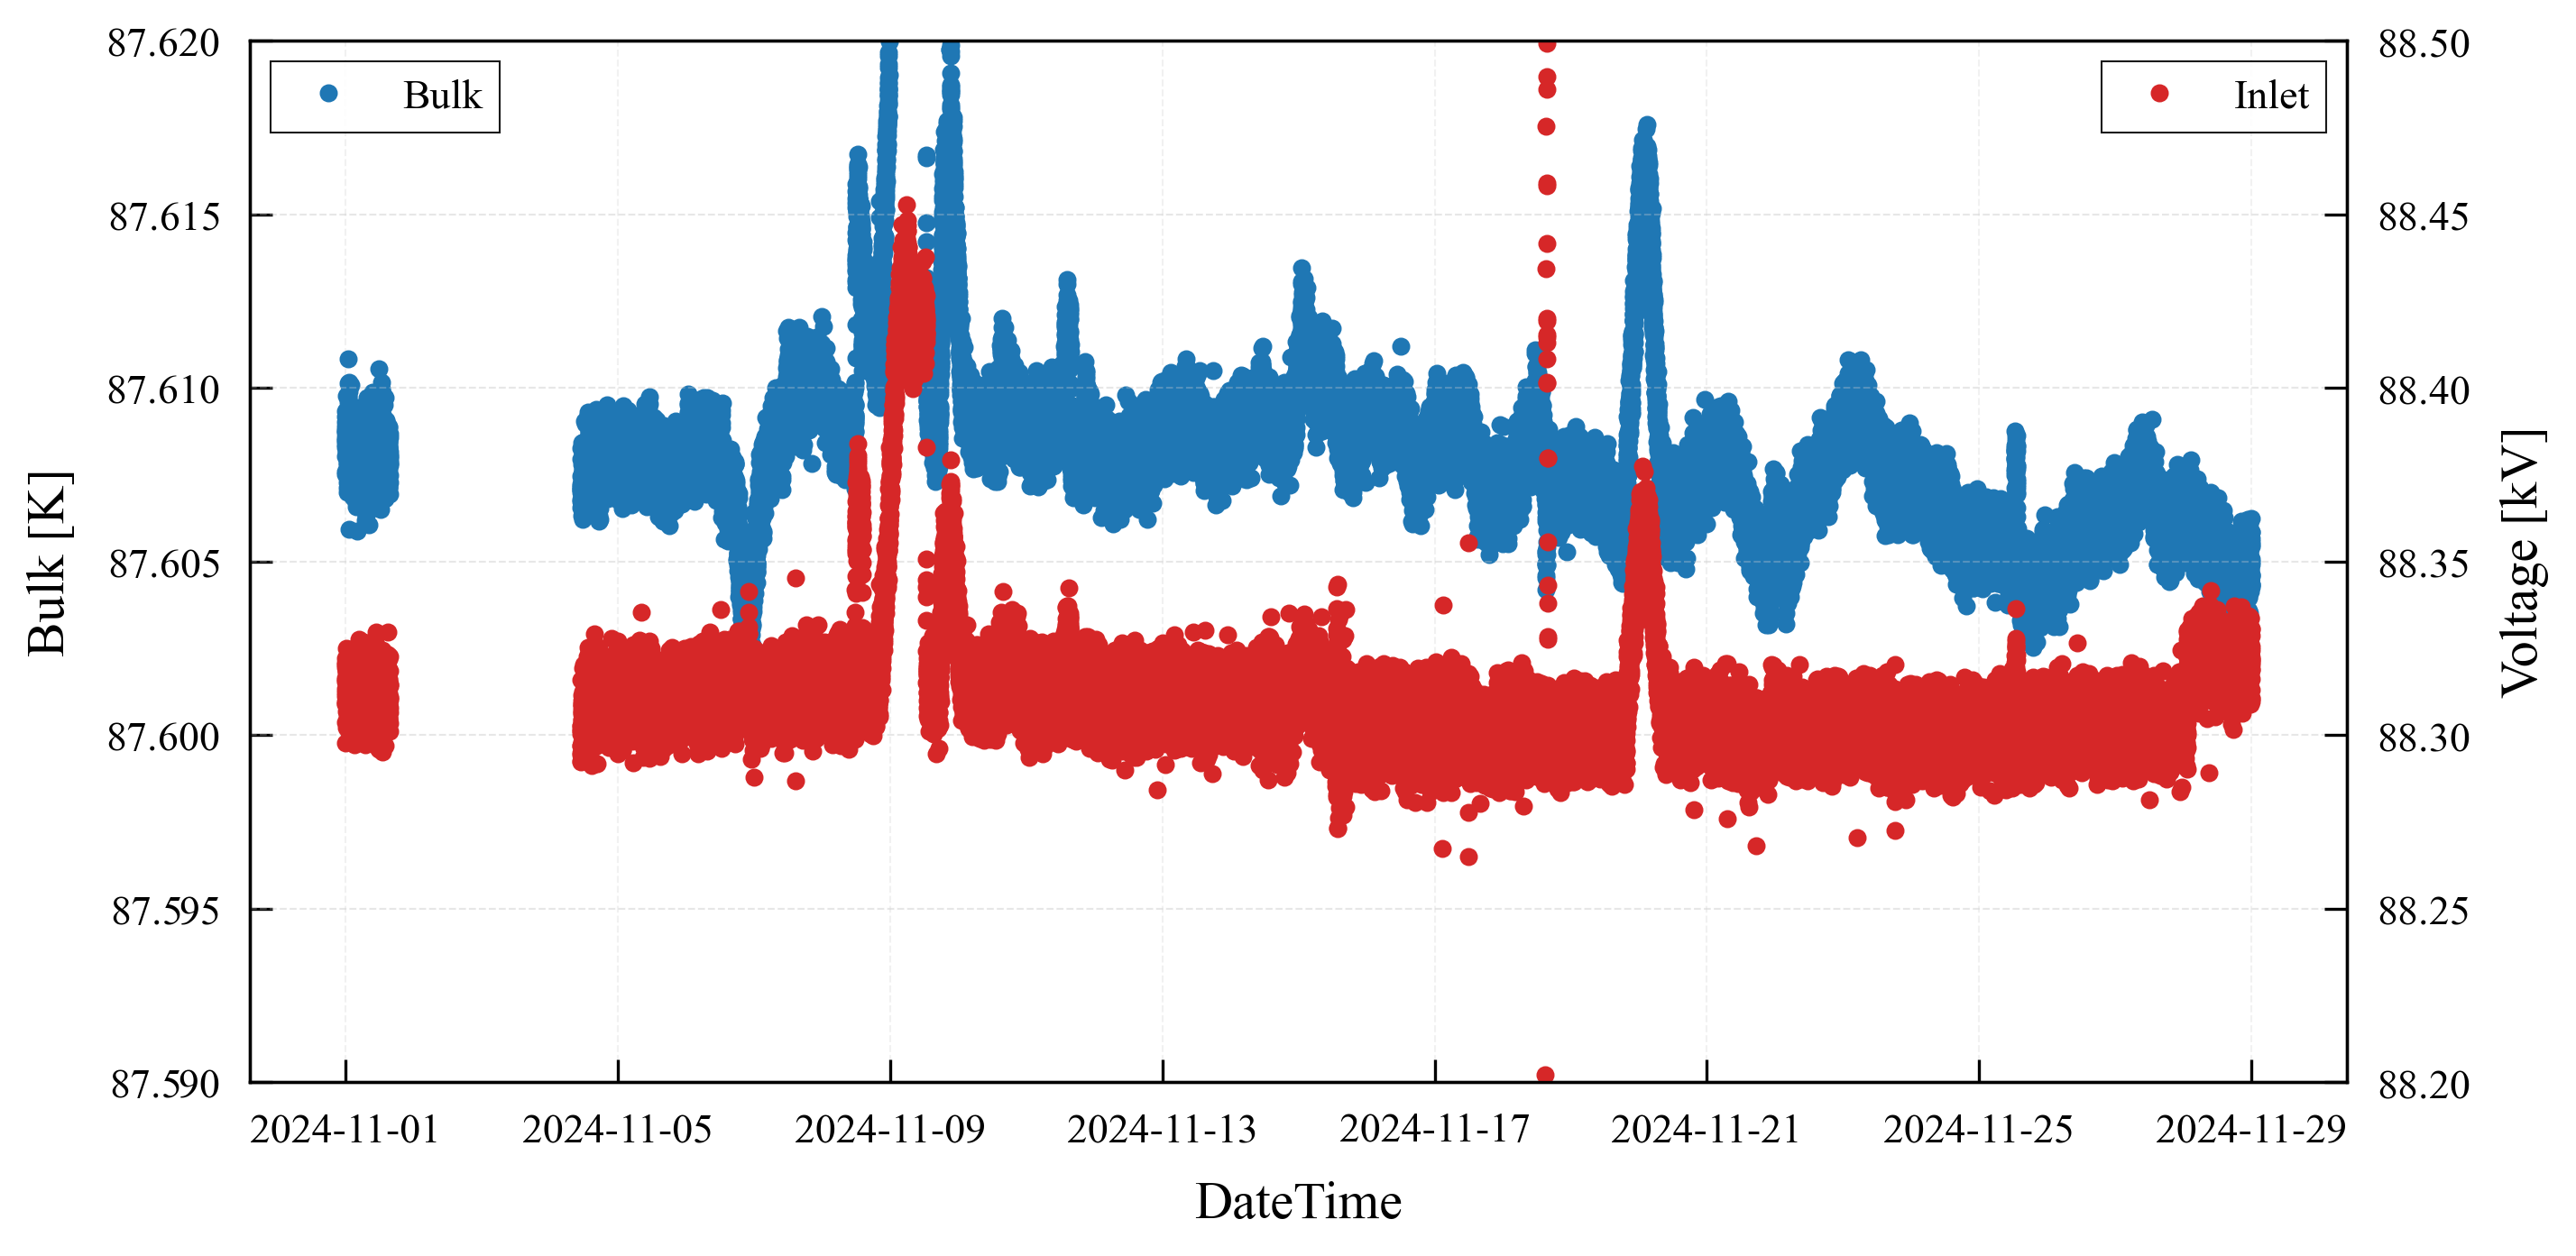

In [72]:
fig, axes = plt.subplots(1,1)
axes.plot(bulk.bulk["october"]["data"]["temp"].index.values, bulk.bulk["october"]["data"]["temp"].values, marker="o", linestyle="None", label="Bulk")
axes.set_xlabel("DateTime")
axes.set_ylabel("Bulk [K]")
axes2 = axes.twinx()
axes2.plot(inlet.sensors[49321].data.index.values, inlet.sensors[49321].data.values, marker="o", linestyle="None", color="tab:red", label="Inlet")

# axes2.plot(hvv.data.index.values, 1e-3*hvv.data.values, marker="o", linestyle="None")
axes2.set_ylabel("Voltage [kV]")
axes.set_ylim(87.59, 87.62)
axes2.set_ylim(88.2, 88.5)
# axes.set_xlim(datetime.datetime(2024, 11, 9), datetime.datetime(2024, 11, 27))
axes.legend(loc="upper left")
axes2.legend(loc="upper right")
fig.set_size_inches(10, 5)



In [26]:
tgrad_stab = tgrad.profile_rms_vs_reference(deltat=5)
prm_stab = prm.profile_rms_vs_reference(deltat=5)
apa1_stab = apa1.profile_rms_vs_reference(deltat=5)
apa2_stab = apa2.profile_rms_vs_reference(deltat=5)
apa3_stab = apa3.profile_rms_vs_reference(deltat=5)
apa4_stab = apa4.profile_rms_vs_reference(deltat=5)
upstream_stab = upstream.profile_rms_vs_reference(deltat=5)
middle_stab = middle.profile_rms_vs_reference(deltat=5)
downstream_stab = downstream.profile_rms_vs_reference(deltat=5)
pumps_stab = pumps.profile_rms_vs_reference(deltat=5)

Calculating TGRAD temperature profiles every 5 minutes: : 1440step [00:17, 84.02step/s]                      
Calculating PRM temperature profiles every 5 minutes: : 1440step [00:02, 676.61step/s]                      
Calculating Custom temperature profiles every 5 minutes: : 1440step [00:00, 1693.07step/s]                      
Calculating Custom temperature profiles every 5 minutes: : 1440step [00:01, 778.88step/s]                      
Calculating Custom temperature profiles every 5 minutes: : 1440step [00:01, 1005.84step/s]                      
Calculating Custom temperature profiles every 5 minutes: : 1440step [00:00, 1739.25step/s]                      
Calculating Custom temperature profiles every 5 minutes: : 1440step [00:00, 1768.79step/s]                      
Calculating Custom temperature profiles every 5 minutes: : 1440step [00:00, 1641.52step/s]                      
Calculating Custom temperature profiles every 5 minutes: : 1440step [00:01, 1010.21step/s]              

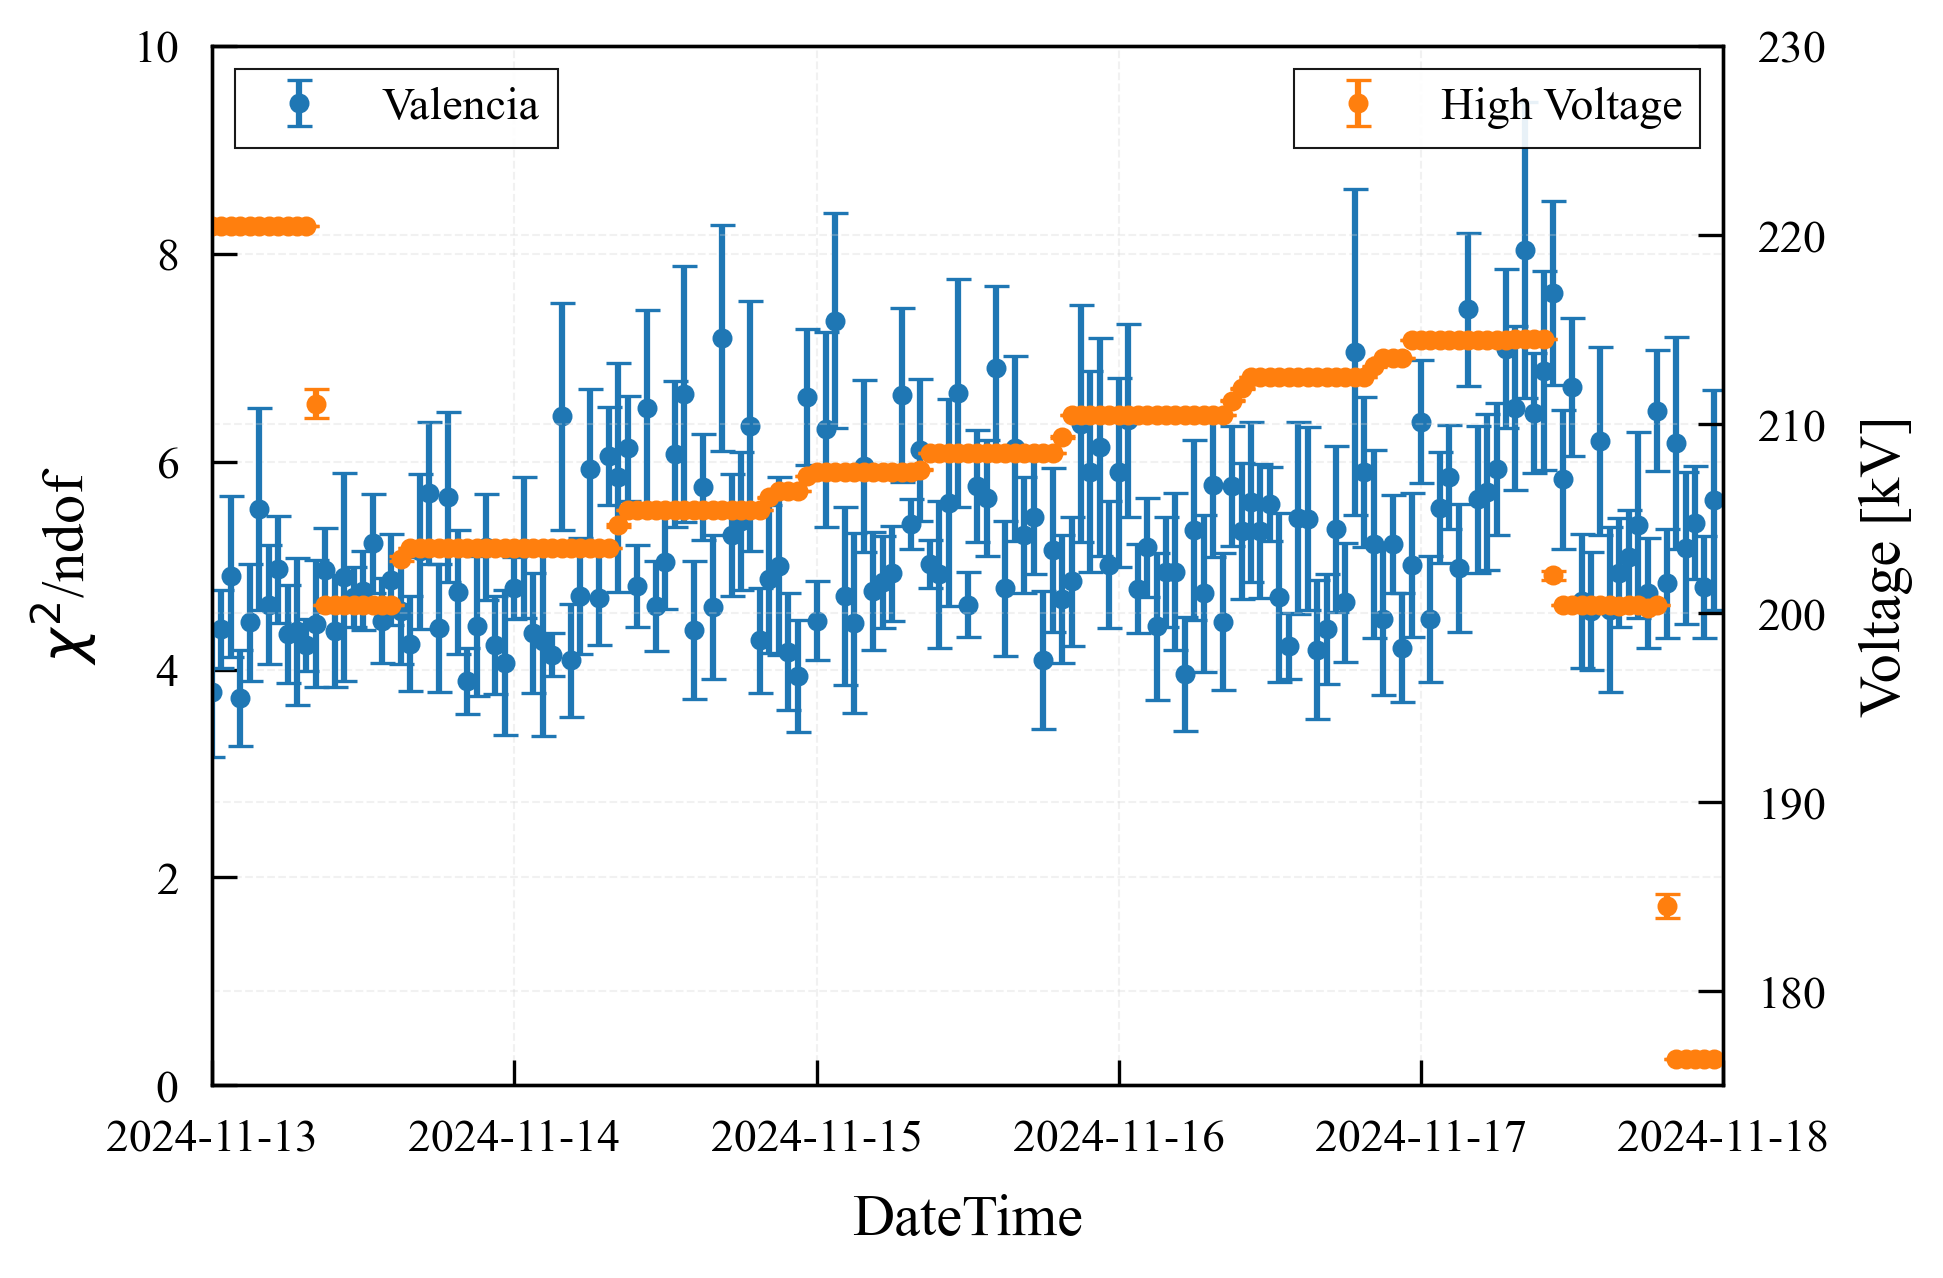

In [34]:
fig, axes = plt.subplots(1,1)
axes2 = axes.twinx()
axes.errorbar(tgrad.stability.resample("45min").mean().index.values, tgrad.stability.resample("45min").mean()["chi2_ndof"].values, yerr=tgrad.stability.resample("45min").sem()["chi2_ndof"].values, marker="o", linestyle="None", label="Valencia")
# axes.plot(prm_stab.index.values, prm_stab["chi2_ndof"].values, marker="o", linestyle="None")
# axes.plot(pumps_stab.index.values, pumps_stab["chi2_ndof"].values, marker="o", linestyle="None")
axes2.errorbar(hvv.data.resample("45min").mean().index.values, 1e-3*hvv.data.resample("45min").mean().values, yerr=1e-3*hvv.data.resample("45min").std().values/np.sqrt(2*(len(hvv.data.resample("45min").mean())-1)), marker="o", linestyle="None", color="tab:orange", label="High Voltage")
axes.set_xlabel("DateTime")
axes.set_ylabel(fr"$\chi^2$/ndof")
axes.set_ylim(0, 10)
axes2.set_ylabel("Voltage [kV]")
axes2.set_ylim(175,230)
# axes.set_xlim(datetime.datetime(2024, 11, 11), datetime.datetime(2024, 11, 29))
axes.legend(loc="upper left")
axes2.legend(loc="upper right")
axes.set_xlim(datetime.datetime(2024, 11, 13), datetime.datetime(2024, 11, 18))
fig.savefig("/Users/jcapo/cernbox/DUNE-IFIC/Publications/NP04_TMS/SENSITIVITY/HV-LADDER_valencia_stability.png")


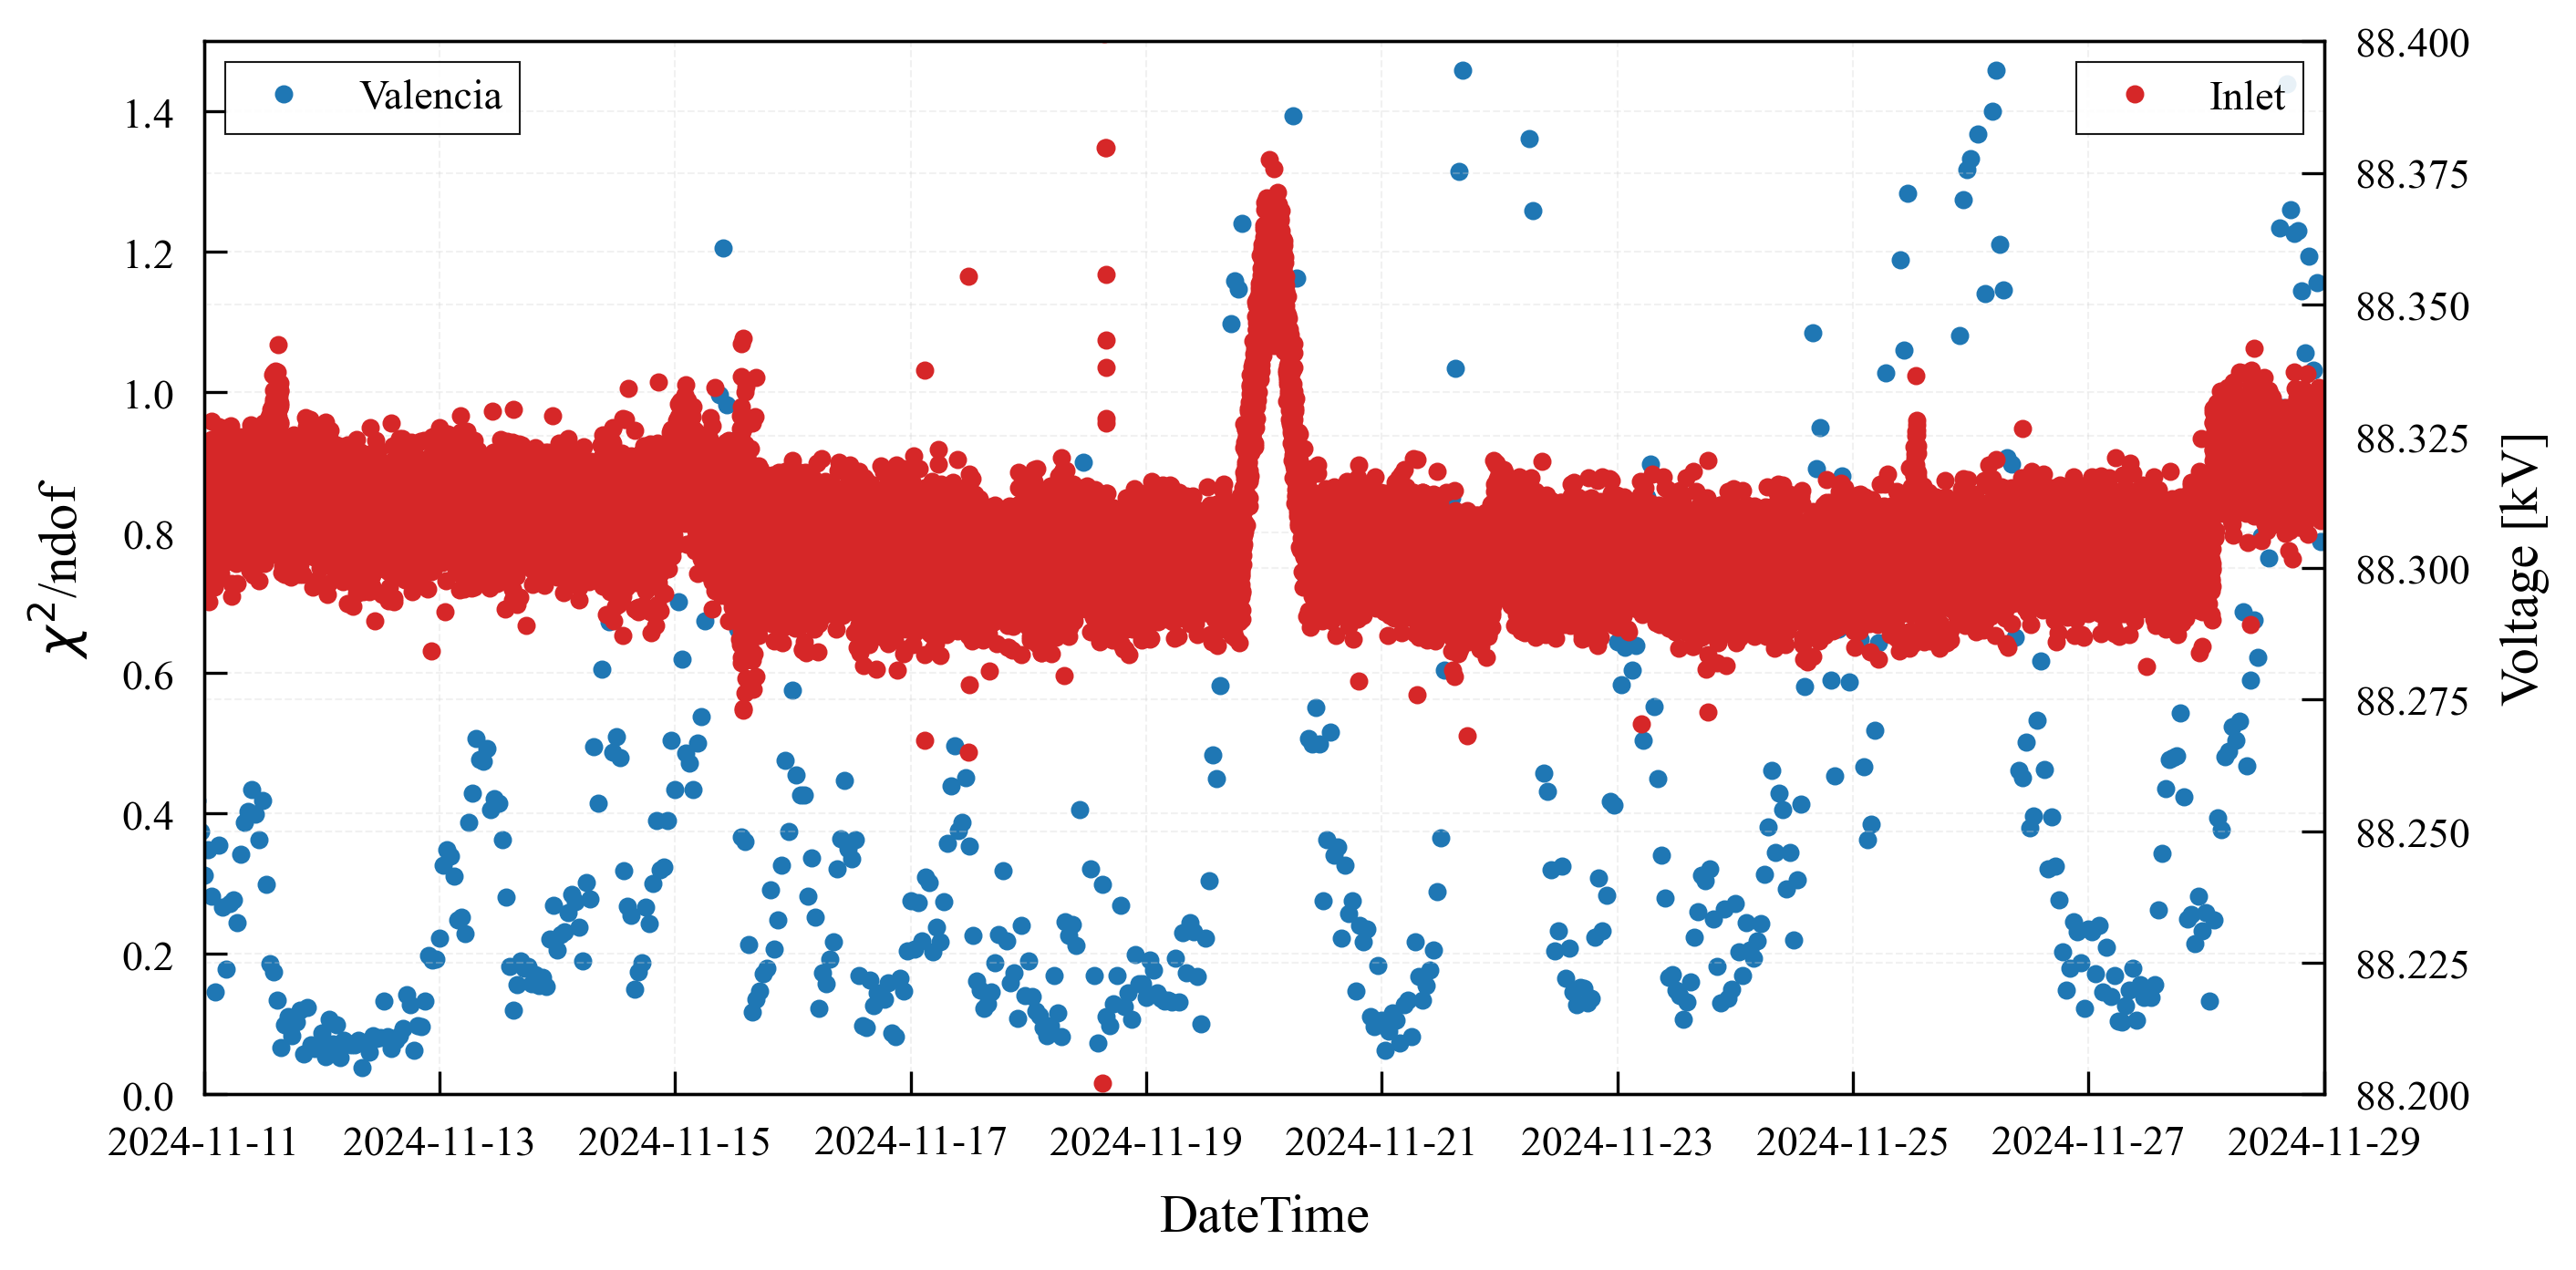

In [90]:
fig, axes = plt.subplots(1,1)
axes2 = axes.twinx()
axes.plot(tgrad_stab.resample("45min").mean().index.values, tgrad_stab.resample("45min").mean()["chi2_ndof"].values, marker="o", linestyle="None", label="Valencia")
axes2.plot(inlet.sensors[49321].data.index.values, inlet.sensors[49321].data.values, marker="o", linestyle="None", color="tab:red", label="Inlet")
axes.set_xlabel("DateTime")
axes.set_ylabel(fr"$\chi^2$/ndof")
axes.set_ylim(0, 1.5)
axes2.set_ylabel("Voltage [kV]")
axes2.set_ylim(88.2, 88.4)
axes.set_xlim(datetime.datetime(2024, 11, 11), datetime.datetime(2024, 11, 29))
axes.legend(loc="upper left")
axes2.legend(loc="upper right")
fig.set_size_inches(10, 5)


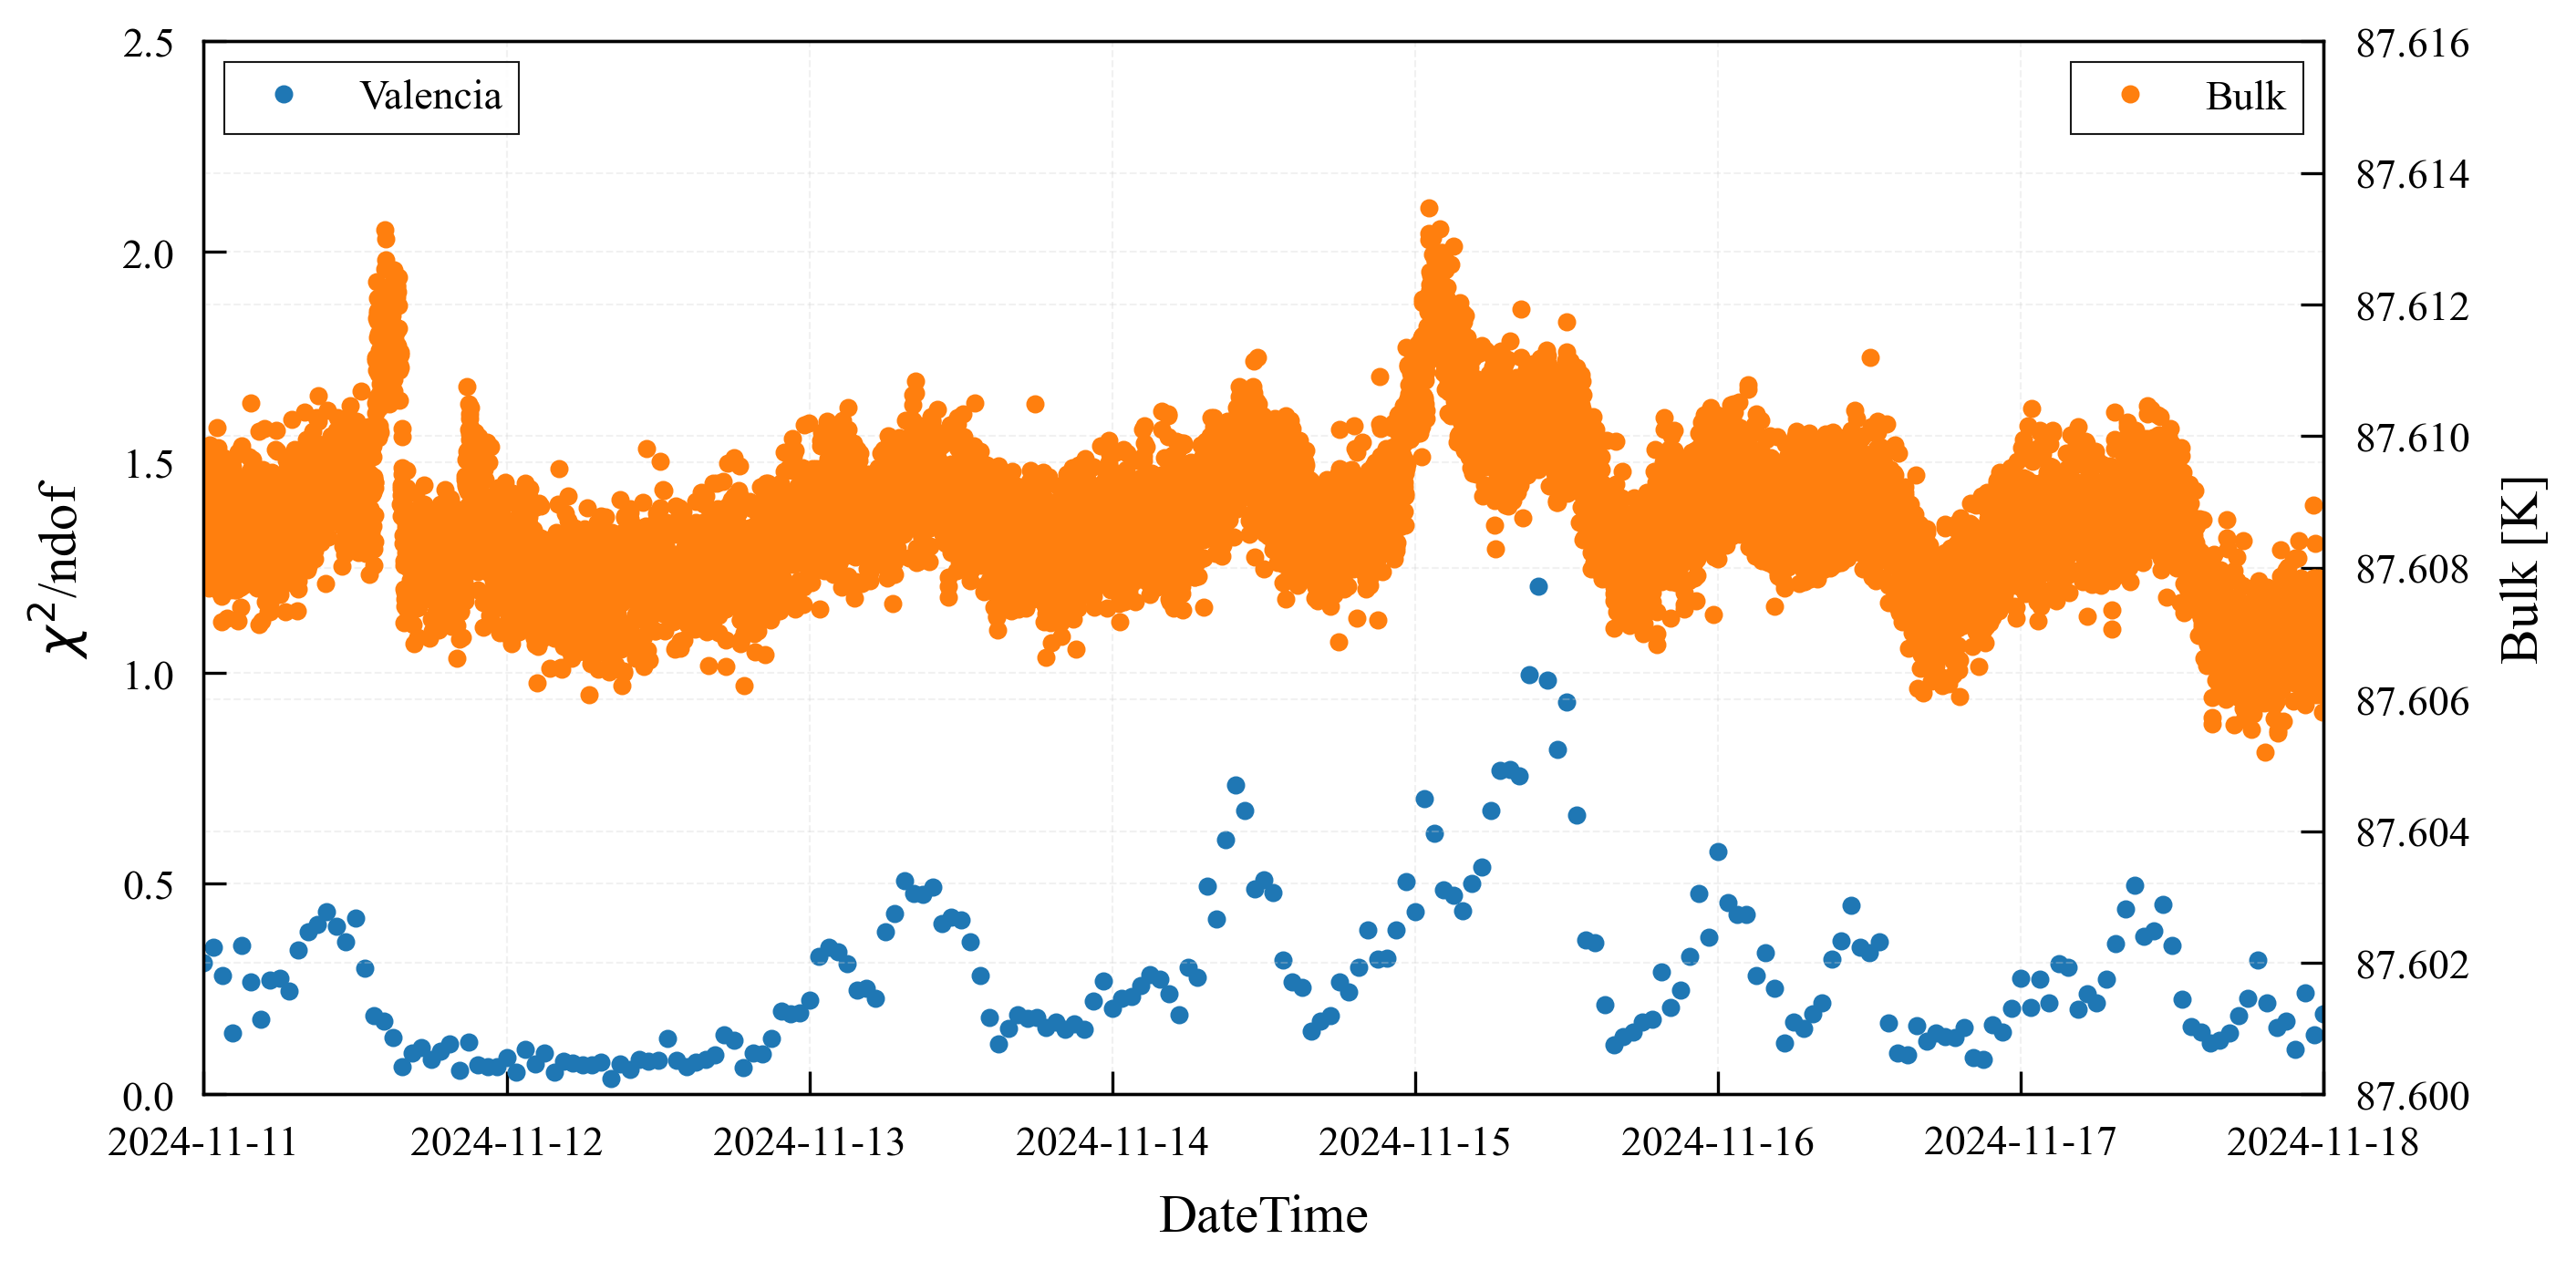

In [86]:
fig, axes = plt.subplots(1,1)
axes2 = axes.twinx()
axes.plot(tgrad_stab.resample("45min").mean().index.values, tgrad_stab.resample("45min").mean()["chi2_ndof"].values, marker="o", linestyle="None", label="Valencia")
axes2.plot(bulk.bulk["october"]["data"]["temp"].index.values, bulk.bulk["october"]["data"]["temp"].values, marker="o", linestyle="None", label="Bulk", color="tab:orange")
axes.set_xlabel("DateTime")
axes.set_ylabel(fr"$\chi^2$/ndof")
axes.set_ylim(0, 2.5)
axes2.set_ylabel("Bulk [K]")
axes2.set_ylim(87.600, 87.616)
axes.set_xlim(datetime.datetime(2024, 11, 11), datetime.datetime(2024, 11, 18))
axes.legend(loc="upper left")
axes2.legend(loc="upper right")
fig.set_size_inches(10, 5)


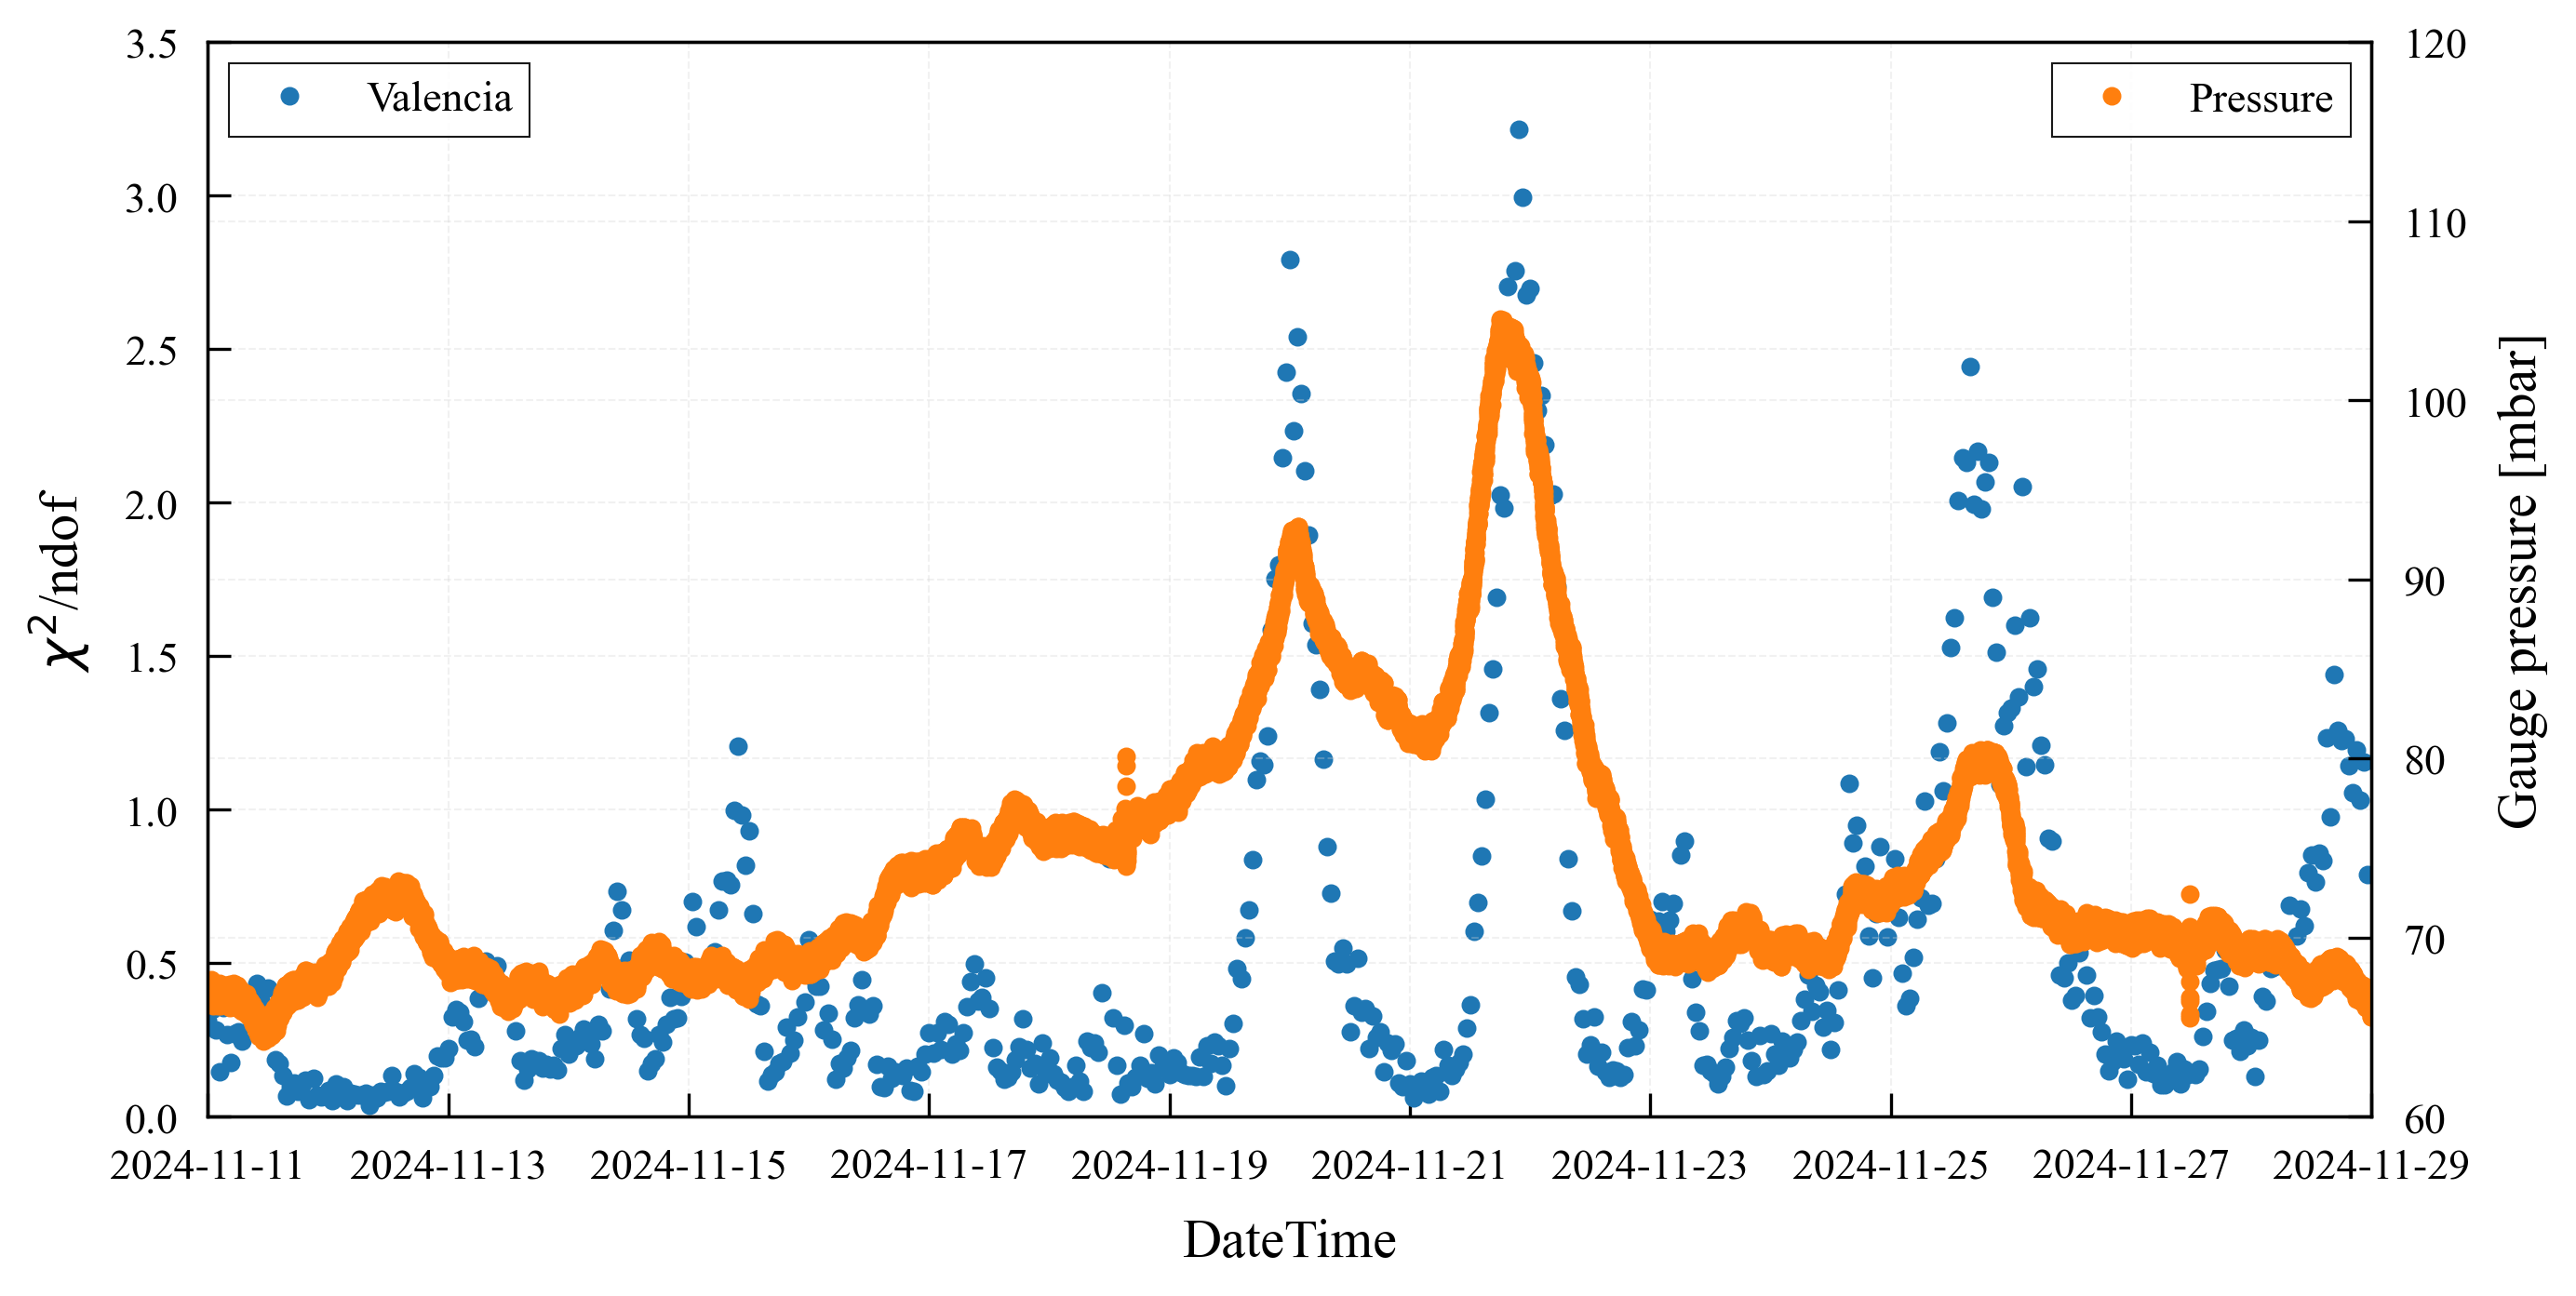

In [91]:
pressure = sensorClasses.Sensor(dataset, id=1015)
fig, axes = plt.subplots(1,1)
axes2 = axes.twinx()
axes.plot(tgrad_stab.resample("45min").mean().index.values, tgrad_stab.resample("45min").mean()["chi2_ndof"].values, marker="o", linestyle="None", label="Valencia")
axes2.plot(pressure.data.index.values, pressure.data.values, marker="o", linestyle="None", label="Pressure", color="tab:orange")
axes.set_xlabel("DateTime")
axes.set_ylabel(fr"$\chi^2$/ndof")
axes.set_ylim(0, 3.5)
axes2.set_ylabel("Gauge pressure [mbar]")
axes2.set_ylim(60, 120)
axes.set_xlim(datetime.datetime(2024, 11, 11), datetime.datetime(2024, 11, 29))
axes.legend(loc="upper left")
axes2.legend(loc="upper right")
fig.set_size_inches(10, 5)